# Sales Effectiveness Prediction - Lead Quality Classification
**Project ID**: PRCL-0019  
**Objective**: Predict high-quality leads to optimize sales team efforts and improve conversion rates using Machine Learning.

#1 — Business Understanding & Problem Framing

- Defined the business objective: Predict high-quality leads to optimize sales efforts and improve conversion rates.
- Identified key stakeholders: Sales Team, Sales Managers, and Marketing Team.
- Framed as a **Binary Classification** problem (High-Quality vs Low-Quality Leads).
- Defined success metrics: ROC-AUC, F1-Score, Precision & Recall with business context.

#2 — Data Loading & Initial Inspection

- Loaded the dataset and performed initial exploration (`shape`, `info()`, `describe()`).
- Identified data types, missing values, and target variable (`Status`).
- Dropped irrelevant columns (`Mobile`, `EMAIL`).

In [1]:
!pip install category_encoders
!pip install pymysql

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.7/45.7 kB 1.5 MB/s eta 0:00:00


In [ ]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler, OneHotEncoder
from sklearn.utils.class_weight import compute_class_weight
from category_encoders import TargetEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier

# Model Building
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor


# Evaluation
from sklearn.model_selection import train_test_split, cross_val_score,RandomizedSearchCV,GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

# Display Settings
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8')

print("All Libraries Imported Successfully!")

# To save the model in pickle file
import joblib

All Libraries Imported Successfully!


## 2. Load Dataset

In [ ]:
"""import pymysql

connection = pymysql.connect(
    host='18.136.157.135',
    user='dm_team2',
    password='DM!$Team&27@9!20!',
    database='project_sales',
    port=3306
)

query = "SELECT * FROM data"

df = pd.read_sql(query, connection)

df"""

'import pymysql\n\nconnection = pymysql.connect(\n    host=\'18.136.157.135\',\n    user=\'dm_team2\',\n    password=\'DM!$Team&27@9!20!\',\n    database=\'project_sales\',\n    port=3306\n)\n\nquery = "SELECT * FROM data"\n\ndf = pd.read_sql(query, connection)\n\ndf'

In [ ]:
# Download dataset from Google Drive
!gdown 1C24UPgwCN8nsuYfz-yg4J1kQkTO_zESP # !pip install gdown


Downloading...
From: https://drive.google.com/uc?id=1C24UPgwCN8nsuYfz-yg4J1kQkTO_zESP
To: /content/sales_data.csv
100% 753k/753k [00:00<00:00, 37.8MB/s]


In [ ]:

# Load your data (update path as needed)
df = pd.read_csv('/content/sales_data.csv')   # or use pd.read_excel

## Basic Data Understanding

In [ ]:
print("Shape:", df.shape)

Shape: (7422, 9)


In [ ]:
df.head()

,Created,Product_ID,Source,Mobile,EMAIL,Sales_Agent,Location,Delivery_Mode,Status
0,14-11-2018 10:05,NaN,Website,984XXXXXXX,aXXXXXXX@gmail.com,Sales-Agent-11,NaN,Mode-5,Open
1,14-11-2018 09:22,NaN,Website,XXXXXXX,#VALUE!,Sales-Agent-10,NaN,Mode-5,Open
2,14-11-2018 09:21,NaN,Website,XXXXXXX,dXXXXXXX@yahoo.com,Sales-Agent-10,NaN,Mode-5,Open
3,14-11-2018 08:46,NaN,Website,XXXXXXX,wXXXXXXX@gmail.com,Sales-Agent-10,NaN,Mode-5,Open
4,14-11-2018 07:34,NaN,Website,XXXXXXX,cXXXXXXX@gmail.com,Sales-Agent-10,NaN,Mode-5,Open


In [ ]:
df.tail()

,Created,Product_ID,Source,Mobile,EMAIL,Sales_Agent,Location,Delivery_Mode,Status
7417,28-04-2018 09:45,9.0,Call,NaN,aXXXXXXX@gmail.com,Sales-Agent-6,Mumbai,Mode-4,LOST
7418,28-04-2018 09:43,15.0,Call,NaN,#VALUE!,Sales-Agent-12,Other Locations,Mode-5,LOST
7419,28-04-2018 09:20,5.0,Live Chat-Direct,NaN,sXXXXXXX@gmail.com,Sales-Agent-11,Bangalore,Mode-1,Not Responding
7420,28-04-2018 08:04,21.0,CRM form,NaN,YXXXXXXX@gmail.com,Sales-Agent-4,Other Locations,Mode-1,Just Enquiry
7421,28-04-2018 07:54,25.0,Website,NaN,cXXXXXXX@gmail.com,Sales-Agent-3,Chennai,Mode-1,CONVERTED


In [ ]:
print("---DATA SHAPE---")
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

---DATA SHAPE---
Rows    : 7422
Columns : 9


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7422 entries, 0 to 7421
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Created        7422 non-null   object 
 1   Product_ID     7364 non-null   float64
 2   Source         7405 non-null   object 
 3   Mobile         5612 non-null   object 
 4   EMAIL          7422 non-null   object 
 5   Sales_Agent    7399 non-null   object 
 6   Location       7364 non-null   object 
 7   Delivery_Mode  7422 non-null   object 
 8   Status         7422 non-null   object 
dtypes: float64(1), object(8)
memory usage: 522.0+ KB


## Observations:
- Dataset contains 7422 records and 9 features
- Most features are categorical
- Product_ID is numerical
- Mobile column has high missing values
- Target variable is Status

The datatypes of this dataset contain mix of
* Integer(0)
* Float(1)
* object(9)

In [ ]:
df.isnull()

,Created,Product_ID,Source,Mobile,EMAIL,Sales_Agent,Location,Delivery_Mode,Status
0,False,True,False,False,False,False,True,False,False
1,False,True,False,False,False,False,True,False,False
2,False,True,False,False,False,False,True,False,False
3,False,True,False,False,False,False,True,False,False
4,False,True,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...
7417,False,False,False,True,False,False,False,False,False
7418,False,False,False,True,False,False,False,False,False
7419,False,False,False,True,False,False,False,False,False
7420,False,False,False,True,False,False,False,False,False


In [ ]:
df.isnull().sum()

,0
Created,0
Product_ID,58
Source,17
Mobile,1810
EMAIL,0
Sales_Agent,23
Location,58
Delivery_Mode,0
Status,0


In [ ]:
print("\n=== CATEGORICAL FEATURES ===")
print(df.select_dtypes(include='object').columns)


=== CATEGORICAL FEATURES ===
Index(['Created', 'Source', 'Mobile', 'EMAIL', 'Sales_Agent', 'Location',
       'Delivery_Mode', 'Status'],
      dtype='object')


In [ ]:
df.describe()

,Product_ID
count,7364.000000
mean,15.947311
std,6.072937
min,0.000000
25%,12.000000
50%,18.000000
75%,19.000000
max,28.000000


### Statistical Summary

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Product_ID,7364.0,15.947311,6.072937,0.0,12.0,18.0,19.0,28.0


In [ ]:
df.describe(include='O')

,Created,Source,Mobile,EMAIL,Sales_Agent,Location,Delivery_Mode,Status
count,7422,7405,5612,7422,7399,7364,7422,7422
unique,6752,25,486,883,12,17,5,11
top,26-09-2018 11:30,Call,XXXXXXX,#VALUE!,Sales-Agent-4,Other Locations,Mode-5,Junk Lead
freq,4,2547,222,1701,1500,2500,2975,1536


In [ ]:
df.describe(include='all')

,Created,Product_ID,Source,Mobile,EMAIL,Sales_Agent,Location,Delivery_Mode,Status
count,7422,7364.000000,7405,5612,7422,7399,7364,7422,7422
unique,6752,NaN,25,486,883,12,17,5,11
top,26-09-2018 11:30,NaN,Call,XXXXXXX,#VALUE!,Sales-Agent-4,Other Locations,Mode-5,Junk Lead
freq,4,NaN,2547,222,1701,1500,2500,2975,1536
mean,NaN,15.947311,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,6.072937,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,12.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,18.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,19.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#3 — Exploratory Data Analysis (EDA)

- Univariate & Bivariate analysis using count plots.
- Analyzed key features: `Delivery_Mode`, `Location`, `Sales_Agent`, `Source`.
- Performed Time-based analysis (Monthly & Day-of-Week trends).
- Conducted Skewness analysis and outlier checks.
- Derived key business insights from visualizations.

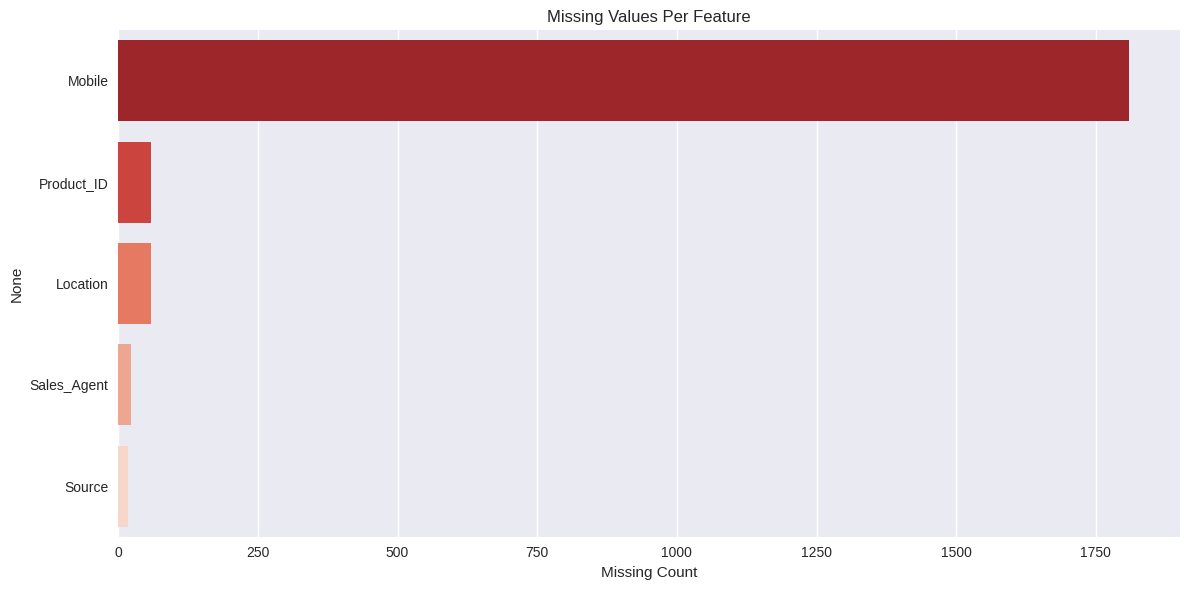

Mobile         1810
Product_ID       58
Location         58
Sales_Agent      23
Source           17
dtype: int64


In [ ]:
# 1) Missing Value Counts
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=missing.values, y=missing.index, palette='Reds_r')# Plot horizontal bar chart of missing values
plt.title('Missing Values Per Feature')
plt.xlabel('Missing Count')
plt.tight_layout()
plt.show()

print(missing) # shows exact count of missing values per feature

In [ ]:
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Percentage': (df.isnull().sum()/len(df))*100
})

missing = missing[missing['Missing Count'] > 0]
missing = missing.sort_values(by='Missing Percentage', ascending=False)

missing

,Missing Count,Missing Percentage
Mobile,1810,24.386958
Product_ID,58,0.781461
Location,58,0.781461
Sales_Agent,23,0.309890
Source,17,0.229049


### Visualization

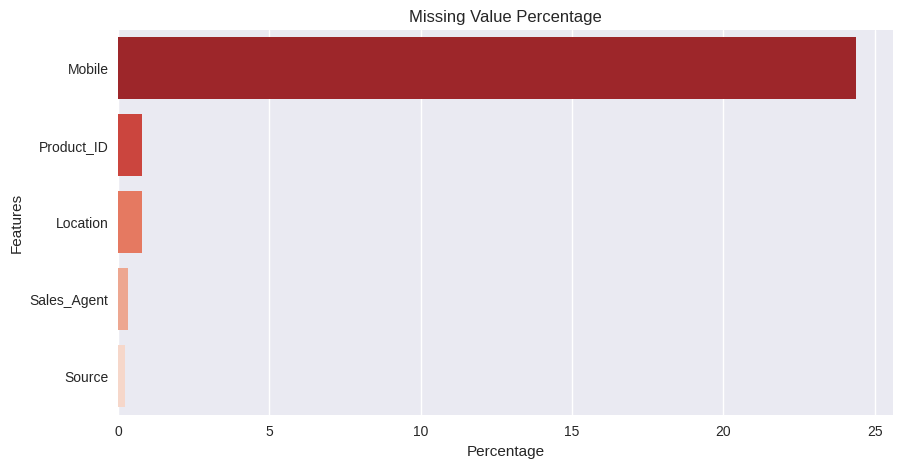

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=missing['Missing Percentage'],
    y=missing.index,
    palette='Reds_r'
)

plt.title("Missing Value Percentage")
plt.xlabel("Percentage")
plt.ylabel("Features")

plt.show()

### Missing Value Relationship

In [ ]:
# pip install missingno
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

### Matrix Plot

<Figure size 1600x800 with 0 Axes>

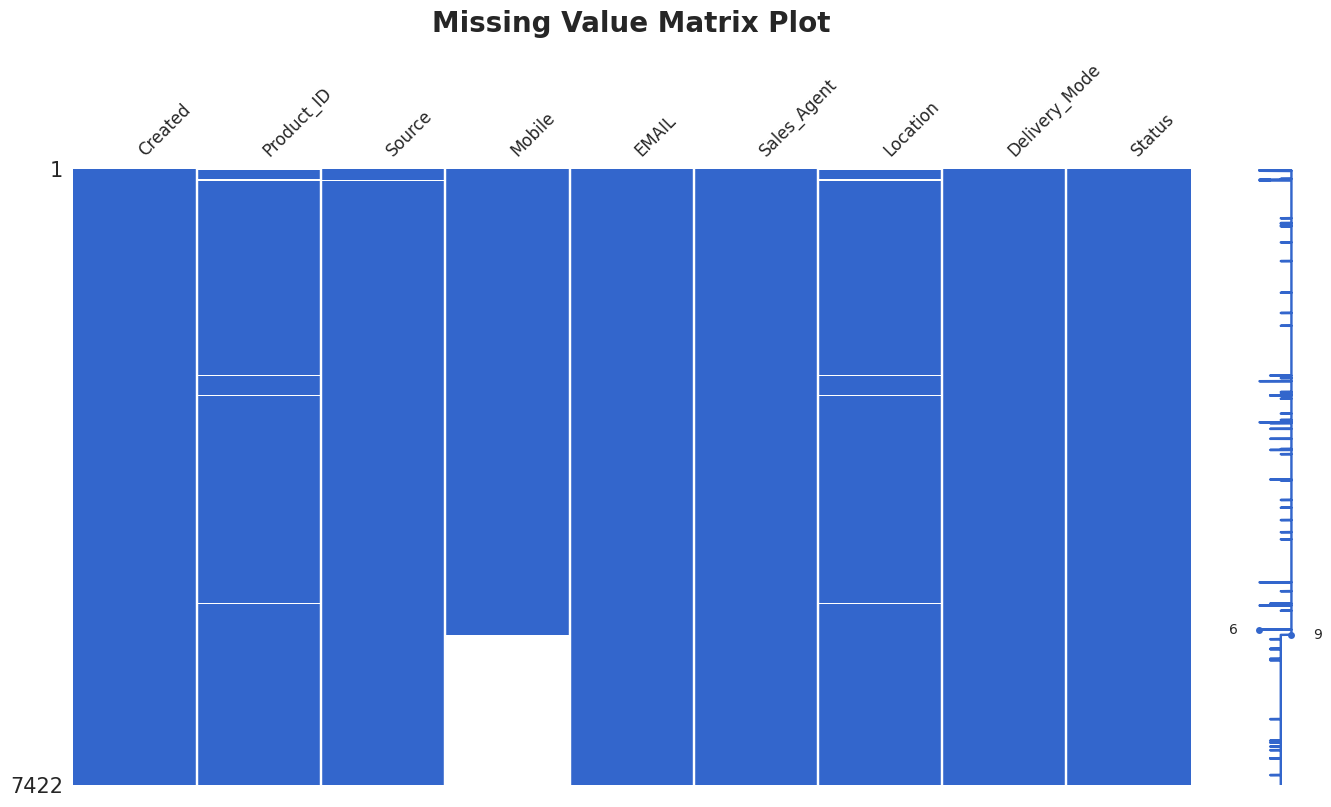

In [ ]:
plt.figure(figsize=(16,8))

msno.matrix(
    df,
    figsize=(16,8),
    color=(0.2, 0.4, 0.8),   # blue tone
    sparkline=True,
    fontsize=12
)

plt.title(
    "Missing Value Matrix Plot",
    fontsize=20,
    fontweight='bold',
    pad=20
)

plt.show()

### Insight:
- The Mobile column contains a high number of missing values.
- Product_ID and Location also have some missing records.
- Missing values are scattered rather than concentrated in specific rows.

### Heatmap

<Figure size 1400x800 with 0 Axes>

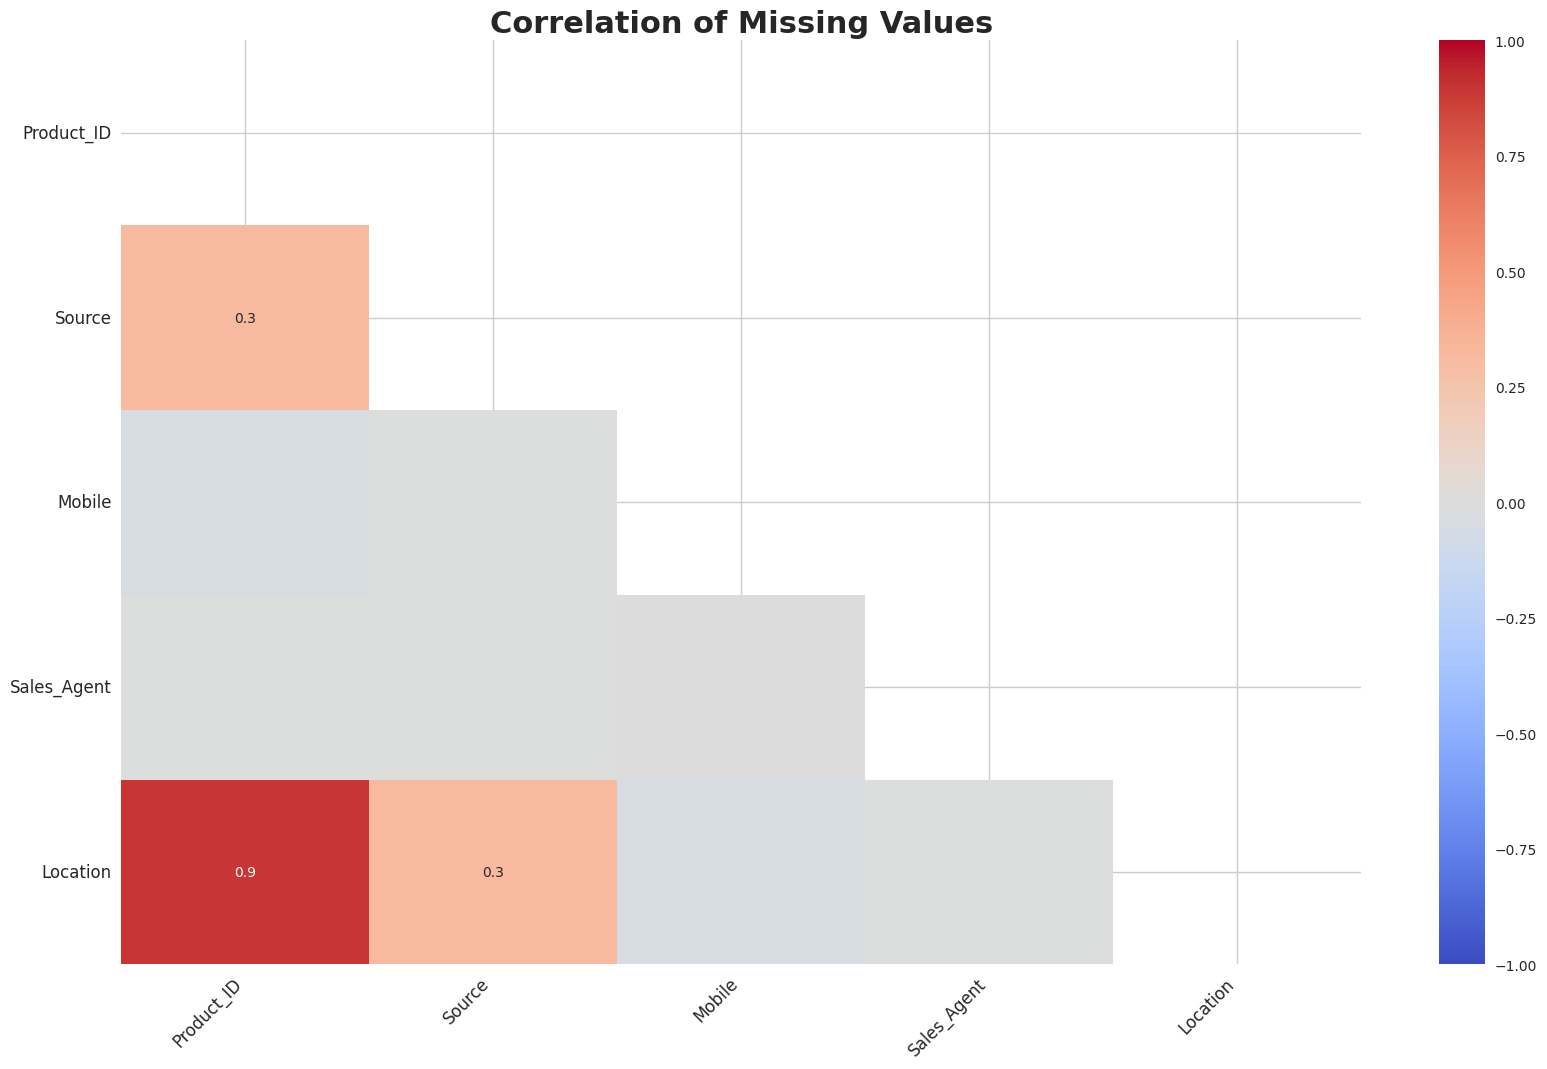

In [ ]:
plt.figure(figsize=(14,8))

msno.heatmap(
    df,
    cmap='coolwarm',
    fontsize=12
)

plt.title(
    "Correlation of Missing Values",
    fontsize=22,
    fontweight='bold'
)

plt.show()

### Interpretation:
- Positive correlation indicates missing values occur together.
- Negative correlation indicates inverse missing patterns.
- Mobile column has the highest missing concentration.

### Missing Value Bar Plot

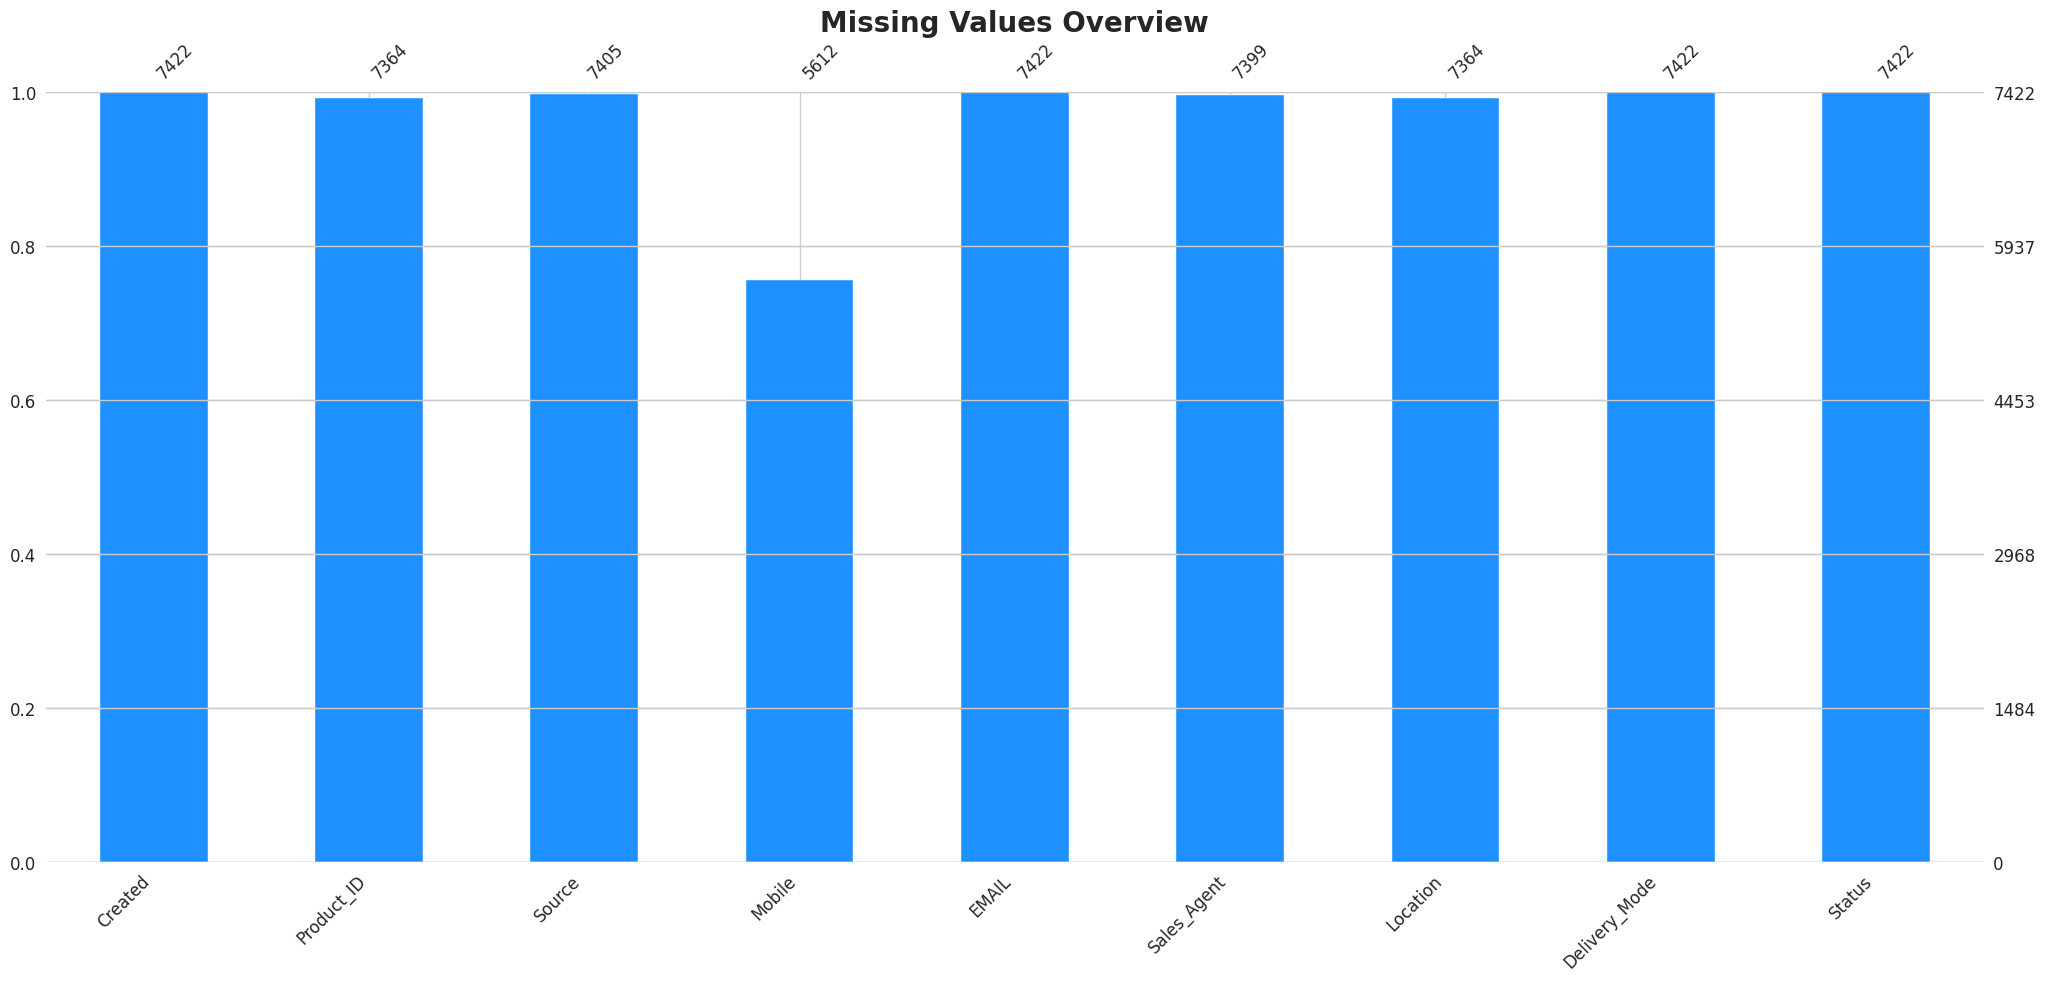

In [ ]:
plt.figure(figsize=(12,6))

msno.bar(
    df,
    color='dodgerblue',
    fontsize=12
)

plt.title(
    "Missing Values Overview",
    fontsize=20,
    fontweight='bold'
)

plt.show()

In [ ]:
plt.style.use('seaborn-v0_8')

sns.set_context("talk")

### Missing Value Bar Chart

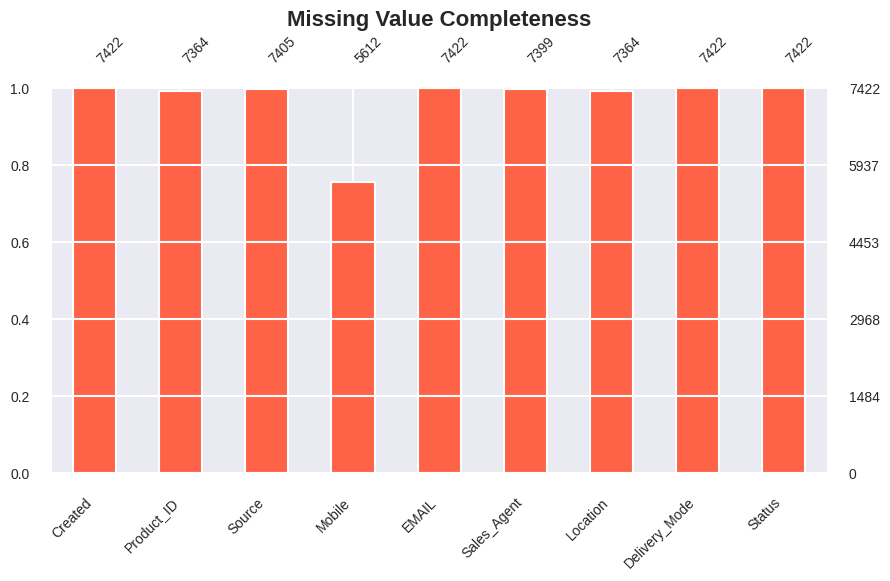

In [ ]:
msno.bar(
    df,
    color='tomato',
    figsize=(10,5),
    fontsize=10
)

plt.title(
    "Missing Value Completeness",
    fontsize=16,
    fontweight='bold'
)

plt.show()

### DENDROGRAM

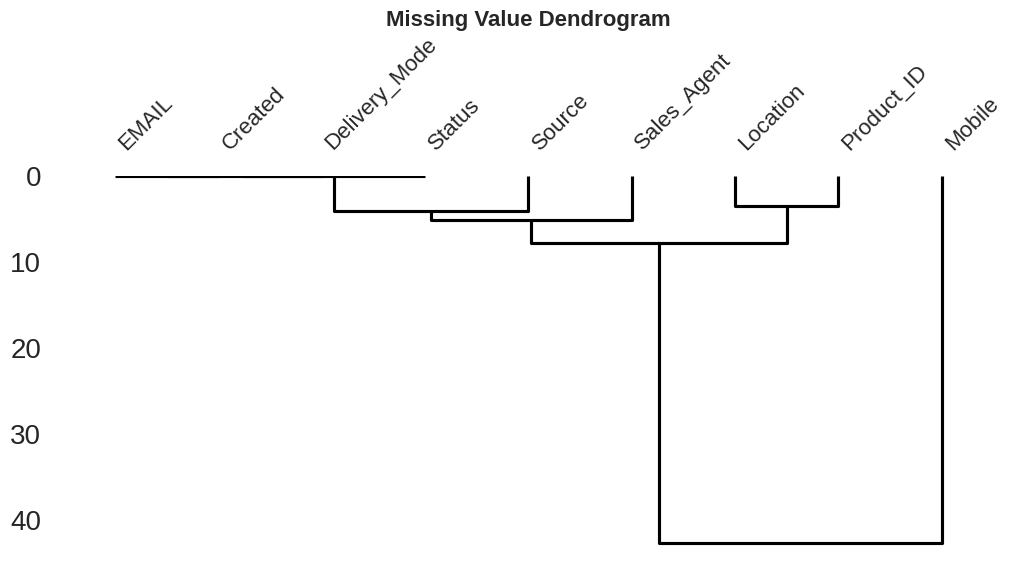

In [ ]:
msno.dendrogram(
    df,
    figsize=(12,5)
)

plt.title(
    "Missing Value Dendrogram",
    fontsize=16,
    fontweight='bold'
)

plt.show()

### Insight:
- Features clustered together indicate similar missing-value patterns.
- Product_ID and Location appear to share similar completeness behavior.

### Target Variable Distribution

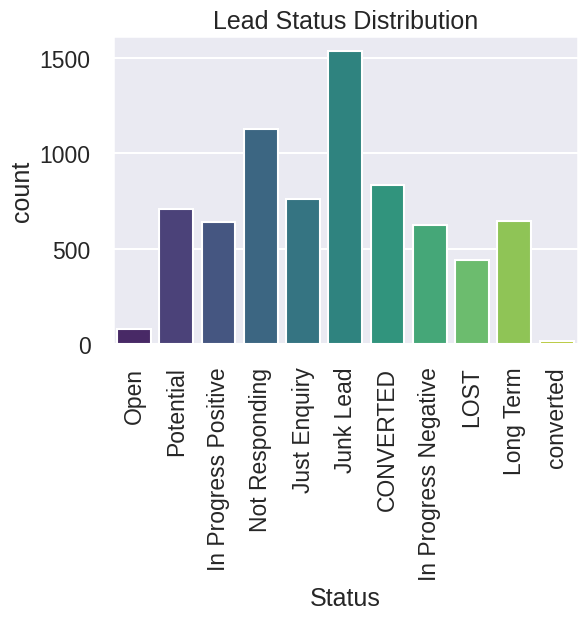

Status
Junk Lead               1536
Not Responding          1129
CONVERTED                834
Just Enquiry             760
Potential                708
Long Term                646
In Progress Positive     643
In Progress Negative     626
LOST                     440
Open                      82
converted                 18
Name: count, dtype: int64


In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Status',
    data=df,
    palette='viridis'
)

plt.title("Lead Status Distribution")
plt.xticks(rotation=90)
plt.show()

print(df['Status'].value_counts())

### Numerical Feature Distribution

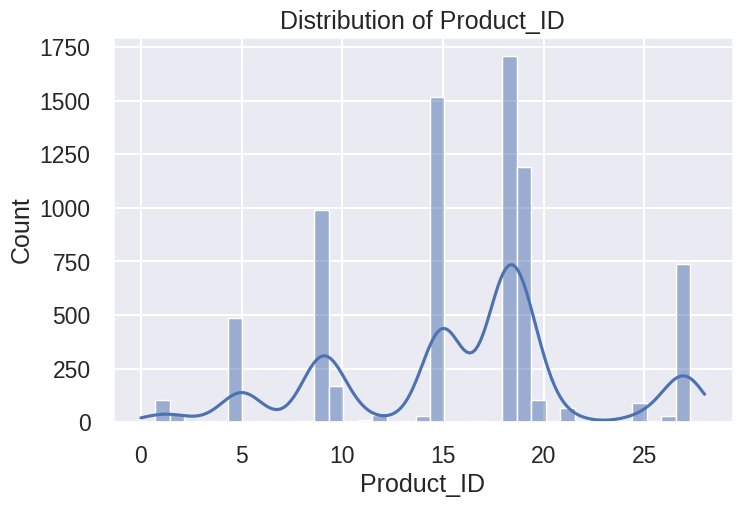

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['Product_ID'], kde=True)

plt.title("Distribution of Product_ID")

plt.show()

### Categorical Feature Analysis

#### Source Distribution

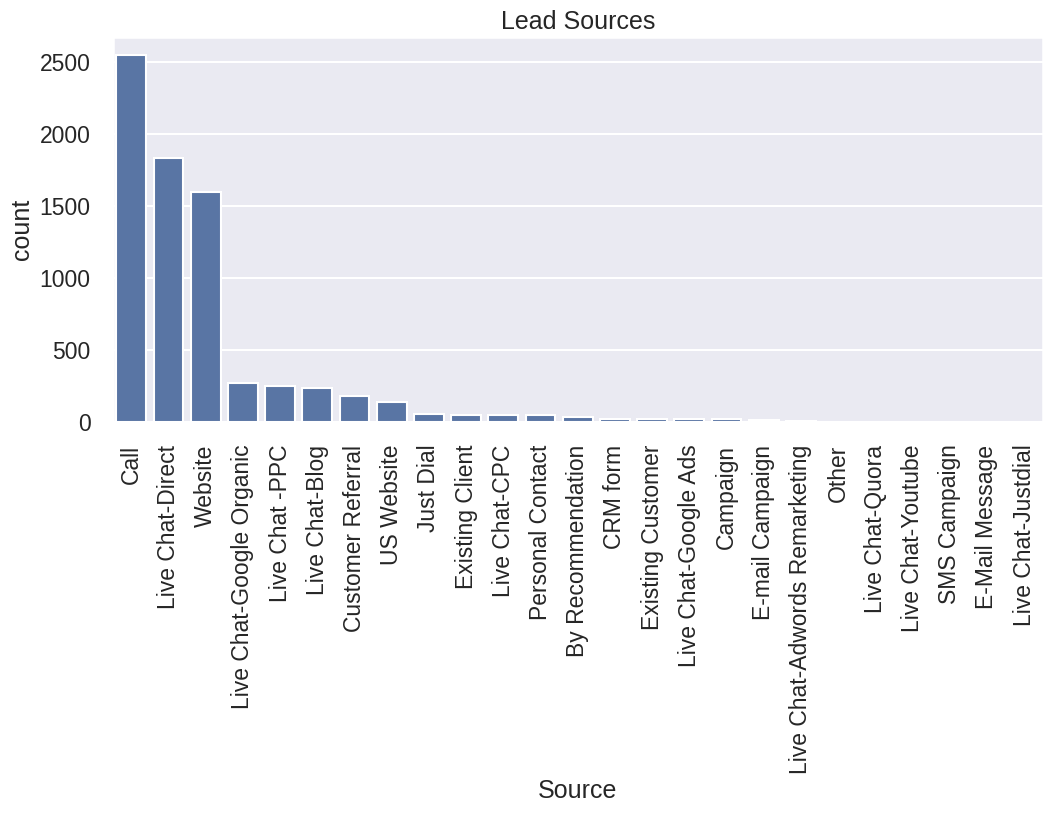

In [ ]:
plt.figure(figsize=(12,5))

sns.countplot(
    x='Source',
    data=df,
    order=df['Source'].value_counts().index
)

plt.xticks(rotation=90)

plt.title("Lead Sources")

plt.show()

#### Delivery Mode Distribution

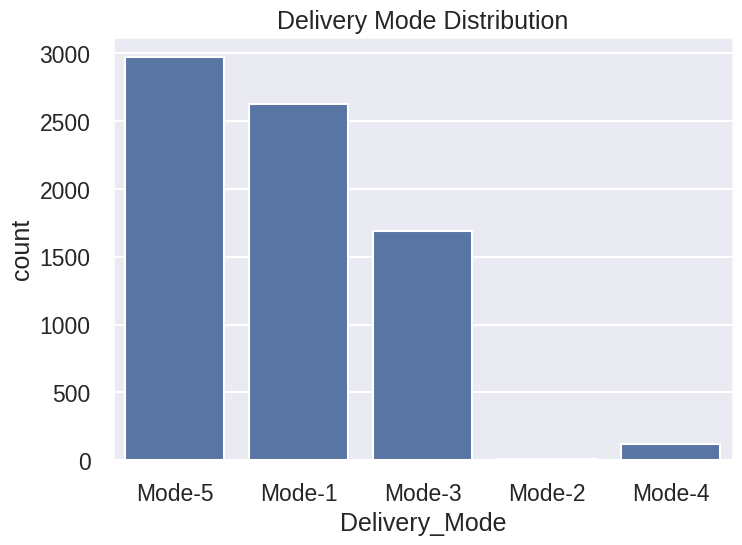

In [ ]:
sns.countplot(
    x='Delivery_Mode',
    data=df
)

plt.title("Delivery Mode Distribution")

plt.show()

### Sales Effectiveness Analysis

#### Source vs Status

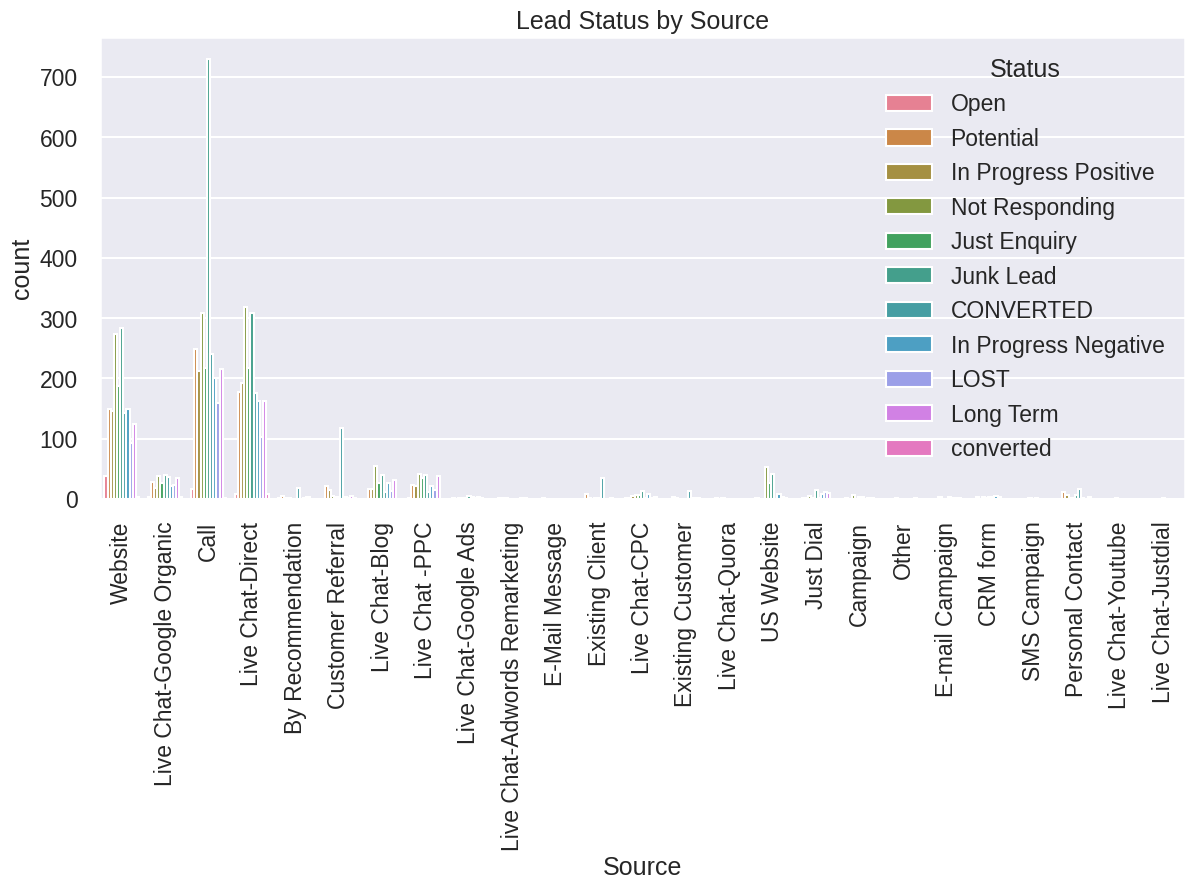

In [ ]:
plt.figure(figsize=(14,6))

sns.countplot(
    x='Source',
    hue='Status',
    data=df
)

plt.xticks(rotation=90)

plt.title("Lead Status by Source")

plt.show()

####  Insight:
- Certain lead sources generate more high-potential leads.
- This can help the company prioritize marketing channels.

### Delivery Mode vs Status

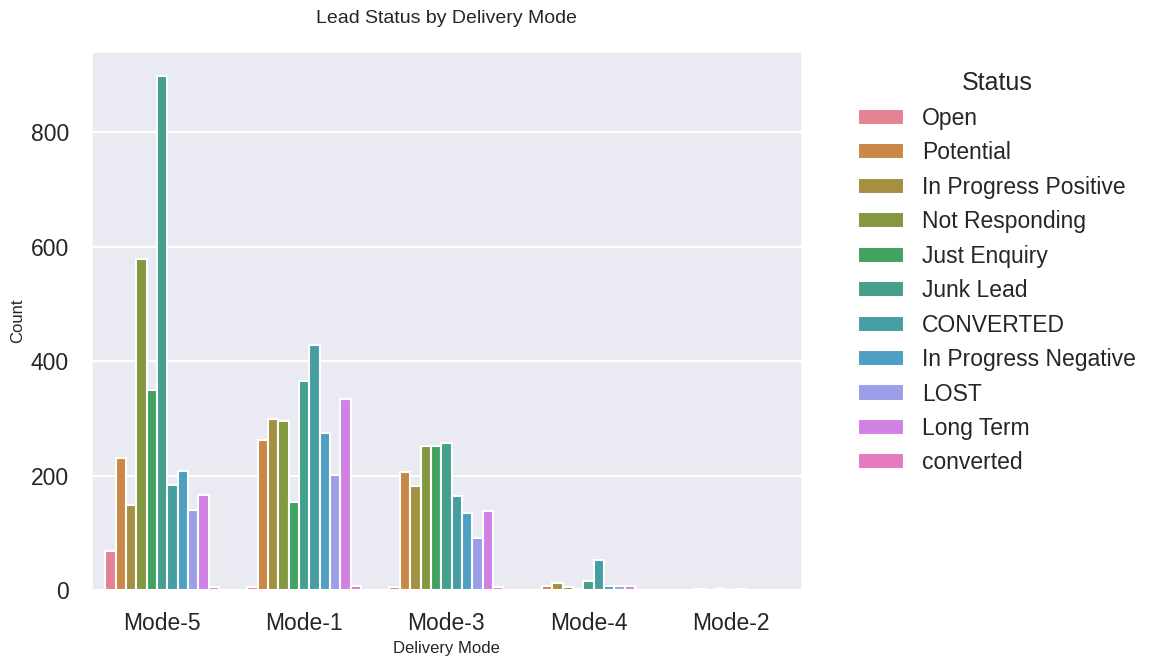

In [ ]:
# Lead Status by Delivery Mode
plt.figure(figsize=(12, 7))
sns.countplot(
    x='Delivery_Mode',
    hue='Status',
    data=df,
    order=df['Delivery_Mode'].value_counts().index
)
plt.title("Lead Status by Delivery Mode", fontsize=14, pad=20)
plt.xlabel("Delivery Mode", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.legend(title="Status", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Location vs Status

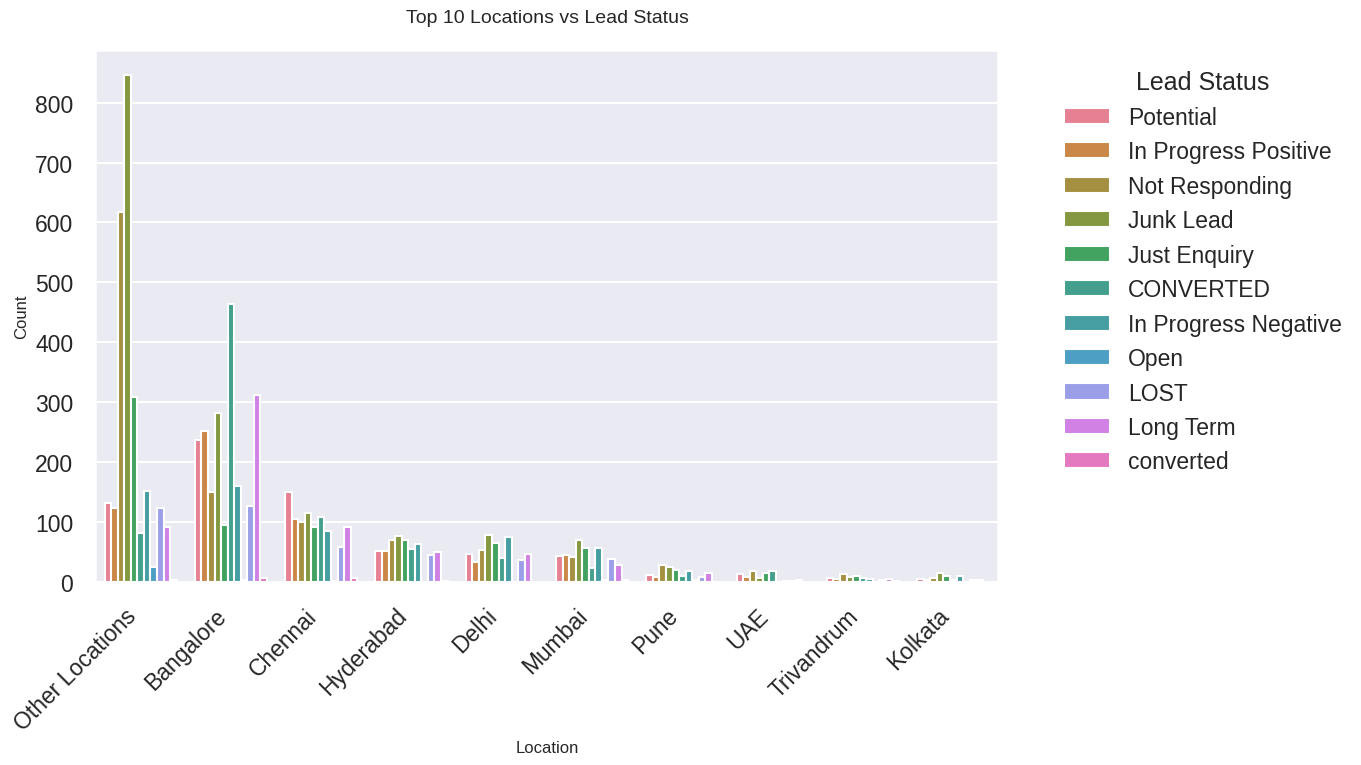

In [ ]:
# Top 10 Locations by Lead Status
top_locations = df['Location'].value_counts().head(10).index

plt.figure(figsize=(14, 8))
sns.countplot(
    x='Location',
    hue='Status',
    data=df[df['Location'].isin(top_locations)],
    order=top_locations
)
plt.title("Top 10 Locations vs Lead Status", fontsize=14, pad=20)
plt.xlabel("Location", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title="Lead Status", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

---
### Key Business Insights — Location-wise Lead Performance

**Location is one of the most important features** for predicting lead quality.

### Major Observations:

- **Bangalore** dominates with the highest number of leads, especially **"Just Enquiry"** and **"In Progress Positive"**. It shows strong volume but also contains many junk/low-quality leads.

- **Chennai, Hyderabad, and Mumbai** show decent activity with a good mix of **"Potential"** and **"CONVERTED"** leads. These cities represent high-potential markets.

- **Delhi, Pune, and Noida** have moderate volume with varying conversion quality.

- Several smaller locations have very low lead counts, indicating limited market penetration.

### Actionable Recommendations for Sales Team:

1. **Prioritize Bangalore** for volume-based campaigns but implement stricter qualification to filter junk leads.
2. **Focus high-effort follow-ups** on leads from **Chennai, Hyderabad, and Mumbai** — these locations show better conversion signals.
3. **Expand presence** in underperforming cities with targeted marketing to increase lead quality.
4. **Location should be given high weight** in the final lead scoring model.

> **Business Impact**: By allocating sales resources intelligently based on location performance, the company can improve conversion rates significantly while optimizing sales team productivity across different regions.

## Correlation between Location & Delivery Mode

From combined analysis:
- Certain Delivery Modes perform better in specific locations (e.g., Mode-1 in Bangalore vs Mode-5 in other cities).
- This interaction can be further explored using `pd.crosstab(df['Location'], df['Delivery_Mode'])` for deeper regional strategy.

In [ ]:
pd.crosstab(df['Location'], df['Delivery_Mode'])

Delivery_Mode,Mode-1,Mode-2,Mode-3,Mode-4,Mode-5
Location,,,,,
AUSTRALIA,3,0,14,2,6
Bangalore,1480,0,131,52,421
Chennai,342,1,240,8,318
Delhi,132,1,177,11,150
EUROPE,0,0,3,0,0
Howrah,0,0,1,0,0
Hyderabad,152,1,205,8,162
Kolkata,4,0,24,1,26
Malaysia,0,0,1,1,2


### Sales Agent Performance

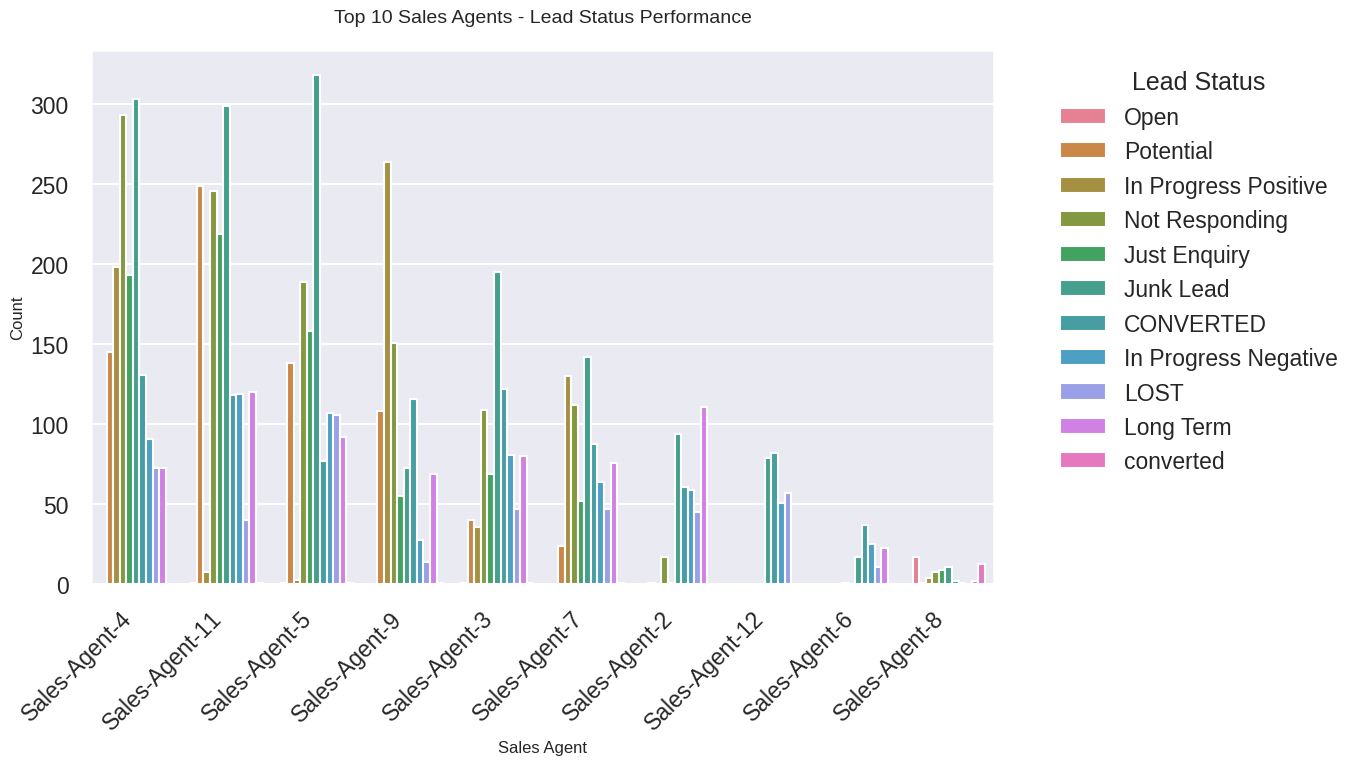

In [ ]:
# Top 10 Sales Agents Performance
top_agents = df['Sales_Agent'].value_counts().head(10).index

plt.figure(figsize=(14, 8))
ax = sns.countplot(
    x='Sales_Agent',
    hue='Status',
    data=df[df['Sales_Agent'].isin(top_agents)],
    order=top_agents
)
plt.title("Top 10 Sales Agents - Lead Status Performance", fontsize=14, pad=20)
plt.xlabel("Sales Agent", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title="Lead Status", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

---
### Key Business Insights — Sales Agent Performance

**Sales Agent is a high-impact feature** in predicting lead conversion.

### Major Observations:

- Some agents (e.g., **Agent-4, Agent-5, Agent-11**) consistently generate high volumes of leads, particularly **"Just Enquiry"** and **"In Progress Positive"**.
- Certain agents show better **conversion quality** (higher proportion of "Potential" and "CONVERTED" leads) compared to others who mostly handle junk or lost leads.
- There is clear variation in performance across agents — indicating differences in skill, experience, or territory assignment.

### Actionable Recommendations for Sales Management:

1. **Identify Top Performers** — Analyze agents with highest conversion rates and replicate their approach (best practices, scripts, follow-up strategy).
2. **Provide Targeted Training** — Agents with high volume but low conversion (mostly "Just Enquiry" / "Junk Lead") need better qualification training.
3. **Performance-Based Incentives** — Link bonuses to lead quality and conversion rate, not just volume.
4. **Agent Assignment Strategy** — Assign high-performing agents to premium locations and high-quality Delivery Modes.
5. **Sales Agent feature should be given significant weight** in the final ML model for lead scoring.

> **Business Impact**: Implementing agent-level insights can dramatically improve overall team conversion rates and help in better resource allocation and training programs.


### Time-Based Analysis

### Convert Date

In [ ]:
# Create Target Variable - Lead Quality
df['Lead_Quality'] = df['Status'].apply(
    lambda x: 1 if str(x).upper() in ['CONVERTED', 'POTENTIAL', 'HIGH POTENTIAL',
                                     'IN PROGRESS POSITIVE', 'WON'] else 0
)

print("Lead_Quality Created Successfully!")
print(df['Lead_Quality'].value_counts(normalize=True))

Lead_Quality Created Successfully!
Lead_Quality
0    0.70318
1    0.29682
Name: proportion, dtype: float64


In [ ]:

# Time Feature Engineering
df['Created'] = pd.to_datetime(df['Created'], format='%d-%m-%Y %H:%M', errors='coerce')
df['Month'] = df['Created'].dt.month
df['Month_Name'] = df['Created'].dt.month_name()
df['DayOfWeek'] = df['Created'].dt.dayofweek
df['DayOfWeek_Name'] = df['Created'].dt.day_name()


### Monthly Lead Trend

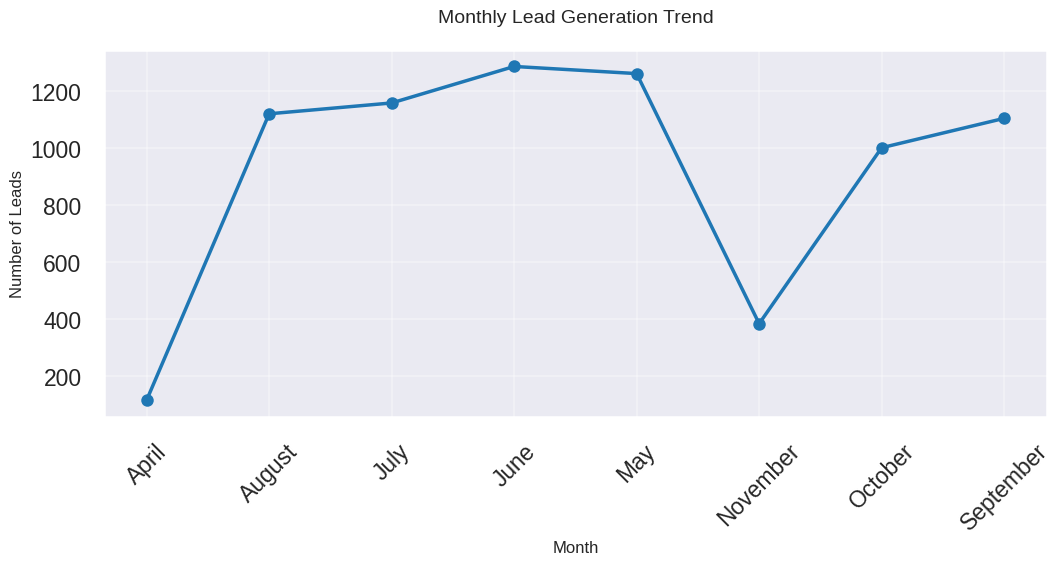

In [ ]:
# 1. Monthly Lead Trend
plt.figure(figsize=(11, 6))
monthly_leads = df.groupby('Month_Name').size()

monthly_leads.plot(
    kind='line',
    marker='o',
    linewidth=2.5,
    color='tab:blue'
)
plt.title("Monthly Lead Generation Trend", fontsize=14, pad=20)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Number of Leads", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Monthly Status Trend

<Figure size 1200x700 with 0 Axes>

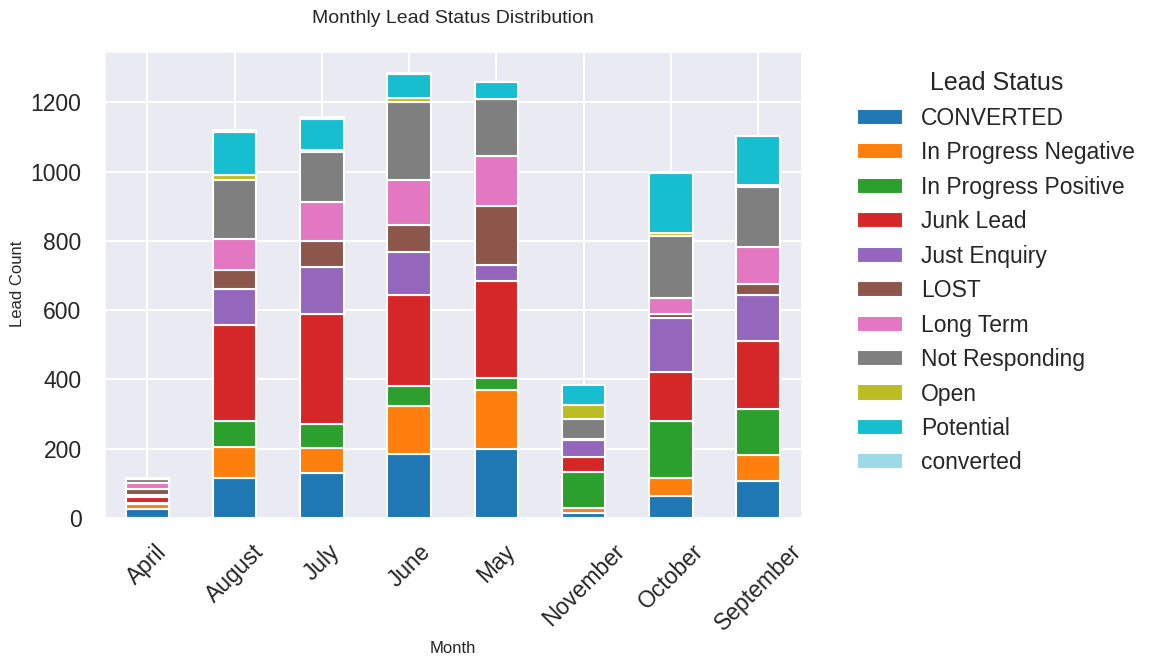

In [ ]:
# 2. Monthly Status Trend
plt.figure(figsize=(12, 7))
monthly_status = pd.crosstab(df['Month_Name'], df['Status'])

monthly_status.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 7),
    colormap='tab20'
)
plt.title("Monthly Lead Status Distribution", fontsize=14, pad=20)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Lead Count", fontsize=12)
plt.legend(title="Lead Status", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Create Target Variable - Lead Quality
df['Lead_Quality'] = df['Status'].apply(
    lambda x: 1 if str(x).upper() in ['CONVERTED', 'POTENTIAL', 'HIGH POTENTIAL',
                                     'IN PROGRESS POSITIVE', 'WON'] else 0
)

print("Lead_Quality Created Successfully!")
print(df['Lead_Quality'].value_counts(normalize=True))

Lead_Quality Created Successfully!
Lead_Quality
0    0.70318
1    0.29682
Name: proportion, dtype: float64


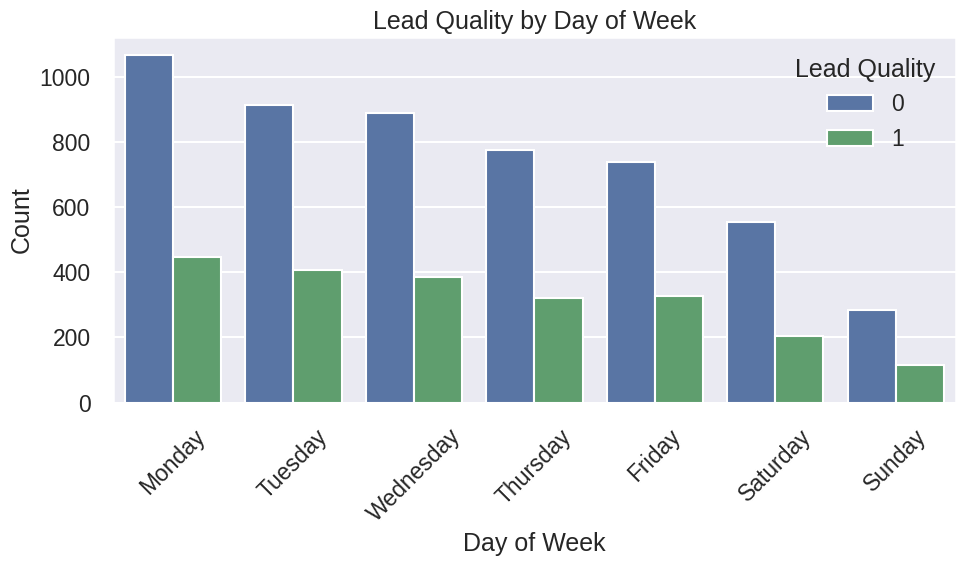

In [ ]:
# Day of Week Analysis
plt.figure(figsize=(10, 6))
sns.countplot(
    x='DayOfWeek_Name',
    hue='Lead_Quality',
    data=df,
    order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
)
plt.title("Lead Quality by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="Lead Quality")
plt.tight_layout()
plt.show()

---
### Key Business Insights — Time-Based Analysis

**Temporal patterns provide valuable insights** for sales planning and resource allocation.
- Monday to Wednesday generate higher volume and better quality leads.
- Weekends (Saturday & Sunday) mostly produce low-quality leads (“Just Enquiry” and “Junk Lead”), indicating less serious buyers.

### Actionable Recommendations for Sales Management:

1. Prioritize follow-ups early in the week (Monday–Wednesday).
2. Reduce effort on weekend-generated leads unless they score high on other factors.
3. Seasonal Strategy — Create month-specific lead nurturing workflows (e.g., stronger follow-ups in low-conversion months).
4. Schedule lead generation campaigns on high-performing weekdays.

> **Business Impact**: Working in sync with weekly patterns helps improve response time on quality leads and optimizes sales team productivity.

### Skewness Analysis

=== Numerical Features Skewness ===

Lead_Quality    0.889648
Product_ID     -0.203658
dtype: float64


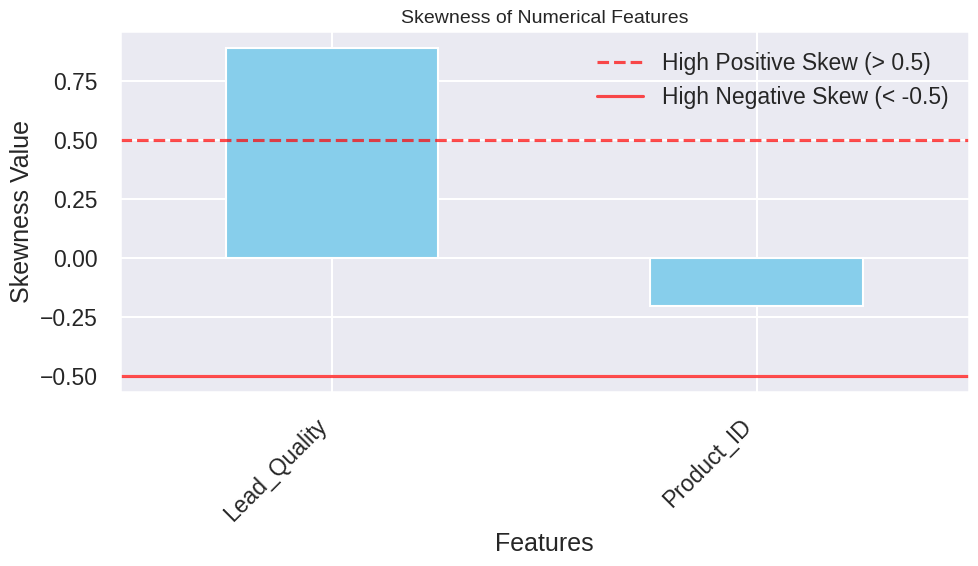

In [ ]:
# Skewness Analysis
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
skewness = df[numerical_cols].skew().sort_values(ascending=False)

print("=== Numerical Features Skewness ===\n")
print(skewness)

# Plot
plt.figure(figsize=(10, 6))
skewness.plot(kind='bar', color='skyblue')
plt.title("Skewness of Numerical Features", fontsize=14)
plt.xlabel("Features")
plt.ylabel("Skewness Value")
plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.7, label='High Positive Skew (> 0.5)')
plt.axhline(y=-0.5, color='red', linestyle='-', alpha=0.7, label='High Negative Skew (< -0.5)')
plt.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---
### Skewness Analysis

#### Key Findings:

- **`Lead_Quality`** → Skewness = **0.89** (Moderately High Positive Skew)  
  This is expected because the target variable is imbalanced (more low-quality leads than high-quality ones).

- **`Product_ID`** → Skewness = **-0.20** (Low Skew)  
  Almost normally distributed.

- No aggressive transformation is applied on the target variable (`Lead_Quality`) as it is problem.

> **Business Insight**: The moderate positive skew in `Lead_Quality` confirms the real-world challenge of **class imbalance** in sales data — there are significantly more low-quality leads than high-quality ones. Our model will focus on correctly identifying the minority high-quality class.

### Log Transformation + Comparison

In [ ]:
# Log Transformation for Comparison
print("=== Skewness Before and After Log Transformation ===\n")

# Original Skewness
original_skew = df[numerical_cols].skew()
print("Original Skewness:\n", original_skew)

# Apply log1p transformation (safe for zero values)
df_transformed = df.copy()
for col in numerical_cols:
    if df[col].min() >= 0:  # Only transform non-negative features
        df_transformed[col] = np.log1p(df[col])

transformed_skew = df_transformed[numerical_cols].skew()
print("\nSkewness After log1p Transformation:\n", transformed_skew)

=== Skewness Before and After Log Transformation ===

Original Skewness:
 Product_ID     -0.203658
Lead_Quality    0.889648
dtype: float64

Skewness After log1p Transformation:
 Product_ID     -1.758528
Lead_Quality    0.889648
dtype: float64


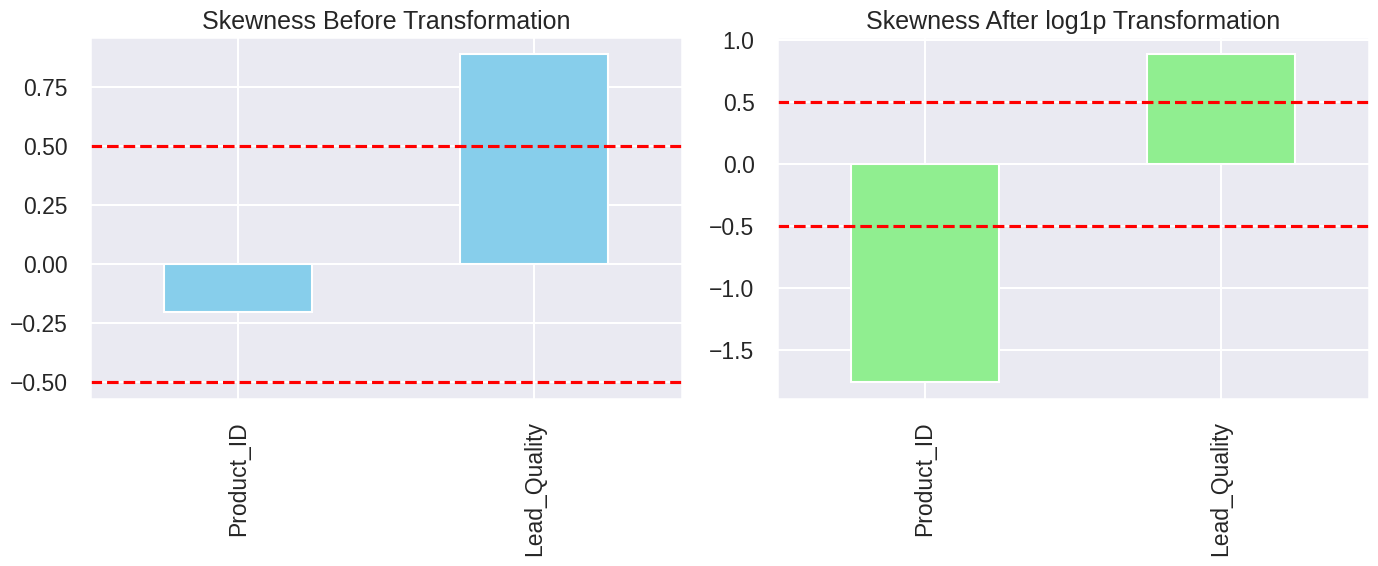

In [ ]:
# Visualization - Before vs After
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

original_skew.plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title("Skewness Before Transformation")
axes[0].axhline(y=0.5, color='red', linestyle='--')
axes[0].axhline(y=-0.5, color='red', linestyle='--')

transformed_skew.plot(kind='bar', ax=axes[1], color='lightgreen')
axes[1].set_title("Skewness After log1p Transformation")
axes[1].axhline(y=0.5, color='red', linestyle='--')
axes[1].axhline(y=-0.5, color='red', linestyle='--')

plt.tight_layout()
plt.show()

---
### Skewness Analysis & Transformation Decision

### Key Findings:
- `Product_ID`: Skewness = **-0.20** (Low / Acceptable)
- `Lead_Quality`: Skewness = **0.89** (Moderate positive skew — expected due to class imbalance)

### Decision:
**No Log Transformation Applied**

**Reasoning:**
- The dataset has very few numerical features.
- Tree-based models (XGBoost, Random Forest, LightGBM) are robust to moderate skewness.
- Log transformation made `Product_ID` **more skewed**, so it was harmful.
- Target variable (`Lead_Quality`) should not be transformed in classification.

> **Conclusion**: We will proceed with the original features. This keeps the data simple and interpretable while maintaining model performance.

---
## Key Business Insights Derived from Visualizations

After extensive Exploratory Data Analysis, the following **actionable insights** were derived:

### 1. Delivery Mode Analysis
- **Mode-1** and **Mode-3** consistently show higher proportions of "Potential" and "CONVERTED" leads.
- **Mode-5** generates the highest volume but contains many "Just Enquiry" and "Junk Lead".
- **Recommendation**: Prioritize follow-ups on Mode-1 & Mode-3 leads.

### 2. Location-wise Performance
- **Bangalore** dominates in lead volume but needs better qualification.
- **Chennai, Hyderabad, and Mumbai** demonstrate stronger lead quality.
- **Recommendation**: Assign experienced sales agents to high-potential cities.

### 3. Sales Agent Performance
- Large variation in performance across agents.
- Some agents excel in converting leads while others generate mostly low-quality ones.
- **Recommendation**: Study top-performing agents and implement best practices across the team.

### 4. Time-Based Patterns
- Clear **monthly seasonality** in lead generation.
- **Monday to Wednesday** show better lead quality compared to weekends.
- **Recommendation**: Align marketing campaigns and sales bandwidth with high-conversion periods.

### Overall Strategic Insight
The combination of **Delivery Mode + Location + Sales Agent** creates strong predictive power for lead quality. These three features should be given high importance in the final model.

> **Business Impact**: Implementing these insights can help the sales team focus efforts on high-potential leads, reduce wasted time on junk leads, and significantly improve overall conversion rates.

---
# **This project is structured in the following 8 Pipeline Stages**
---

# Stage 1 — Data Cleaning & Initial Inspection

- Loaded the dataset and performed initial exploration (`info()`, `describe()`, `isnull().sum()`).
- Identified data types and missing values.
- Dropped irrelevant/PII columns (`Mobile`, `EMAIL`).
- Checked for duplicates and basic data quality issues.

In [ ]:
print("=== Dataset Information ===")
print(df.info())

=== Dataset Information ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7422 entries, 0 to 7421
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Created         7422 non-null   datetime64[ns]
 1   Product_ID      7364 non-null   float64       
 2   Source          7405 non-null   object        
 3   Mobile          5612 non-null   object        
 4   EMAIL           7422 non-null   object        
 5   Sales_Agent     7399 non-null   object        
 6   Location        7364 non-null   object        
 7   Delivery_Mode   7422 non-null   object        
 8   Status          7422 non-null   object        
 9   Lead_Quality    7422 non-null   int64         
 10  Month           7422 non-null   int32         
 11  Month_Name      7422 non-null   object        
 12  DayOfWeek       7422 non-null   int32         
 13  DayOfWeek_Name  7422 non-null   object        
dtypes: datetime64[ns](1), float6

In [ ]:
display(df.head())

,Created,Product_ID,Source,Mobile,EMAIL,Sales_Agent,Location,Delivery_Mode,Status,Lead_Quality,Month,Month_Name,DayOfWeek,DayOfWeek_Name
0,2018-11-14 10:05:00,NaN,Website,984XXXXXXX,aXXXXXXX@gmail.com,Sales-Agent-11,NaN,Mode-5,Open,0,11,November,2,Wednesday
1,2018-11-14 09:22:00,NaN,Website,XXXXXXX,#VALUE!,Sales-Agent-10,NaN,Mode-5,Open,0,11,November,2,Wednesday
2,2018-11-14 09:21:00,NaN,Website,XXXXXXX,dXXXXXXX@yahoo.com,Sales-Agent-10,NaN,Mode-5,Open,0,11,November,2,Wednesday
3,2018-11-14 08:46:00,NaN,Website,XXXXXXX,wXXXXXXX@gmail.com,Sales-Agent-10,NaN,Mode-5,Open,0,11,November,2,Wednesday
4,2018-11-14 07:34:00,NaN,Website,XXXXXXX,cXXXXXXX@gmail.com,Sales-Agent-10,NaN,Mode-5,Open,0,11,November,2,Wednesday


In [ ]:
print("\n=== Statistical Summary ===")
display(df.describe())


=== Statistical Summary ===


,Created,Product_ID,Lead_Quality,Month,DayOfWeek
count,7422,7364.000000,7422.000000,7422.000000,7422.000000
mean,2018-07-31 21:27:37.849636352,15.947311,0.296820,7.499461,2.370385
min,2018-04-28 07:54:00,0.000000,0.000000,4.000000,0.000000
25%,2018-06-12 15:32:00,12.000000,0.000000,6.000000,1.000000
50%,2018-07-30 11:39:30,18.000000,0.000000,7.000000,2.000000
75%,2018-09-18 14:03:45,19.000000,1.000000,9.000000,4.000000
max,2018-11-14 10:05:00,28.000000,1.000000,11.000000,6.000000
std,NaN,6.072937,0.456887,1.877802,1.831863


## Missing Values Check

In [ ]:
missing = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Values': missing, 'Percentage': missing_percent})
print(missing_df[missing_df['Missing Values'] > 0])

             Missing Values  Percentage
Product_ID               58    0.781461
Source                   17    0.229049
Mobile                 1810   24.386958
Sales_Agent              23    0.309890
Location                 58    0.781461


In [ ]:
# 4. Drop Irrelevant / PII Columns
drop_cols = ['Mobile', 'EMAIL']
df = df.drop(columns=[col for col in drop_cols if col in df.columns])

print(f"\nDropped columns: {drop_cols}")
print(f"Shape after dropping columns: {df.shape}")

# 5. Check for Duplicates
duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicates}")

if duplicates > 0:
    df = df.drop_duplicates()
    print("Duplicates removed.")


Dropped columns: ['Mobile', 'EMAIL']
Shape after dropping columns: (7422, 12)

Number of duplicate rows: 11
Duplicates removed.


---
## Stage 1 — Data Cleaning & Initial Inspection

**Activities Completed:**

- Successfully loaded the sales leads dataset.
- Performed initial exploration using `info()`, `describe()`, and `head()`.
- Analyzed data types and identified columns with missing values.
- Dropped irrelevant/PII columns (`Mobile`, `EMAIL`) to protect privacy and reduce noise.
- Checked for duplicate records.
- Understood the basic structure and quality of the data.

**Outcome:**  
A cleaner dataset ready for deeper Exploratory Data Analysis. No major data quality issues were found after initial cleaning.

**Next Stage:** Feature Engineering

# Stage 2 — Feature Engineering & Preprocessing

- Created target variable `Lead_Quality` from `Status`.
- Extracted time features: `Month`, `DayOfWeek`.
- Handled missing values using appropriate imputation strategies.

## 1. Create Target Variable

In [ ]:
# Check if 'Status' column exists before creating target
if 'Status' in df.columns:
    # 1. Create Target Variable
    df['Lead_Quality'] = df['Status'].apply(
        lambda x: 1 if str(x).upper() in ['CONVERTED', 'POTENTIAL', 'HIGH POTENTIAL',
                                          'IN PROGRESS POSITIVE', 'WON'] else 0
    )
    print("✅ Target Variable 'Lead_Quality' Created from 'Status' column")
else:
    print("⚠️  'Status' column not found. Checking if 'Lead_Quality' already exists...")
    if 'Lead_Quality' not in df.columns:
        print("❌ Lead_Quality also not found. Please check your dataframe columns.")
        print("Available Columns:", df.columns.tolist())

print("\nTarget Distribution:")
print(df['Lead_Quality'].value_counts(normalize=True))

✅ Target Variable 'Lead_Quality' Created from 'Status' column

Target Distribution:
Lead_Quality
0    0.702874
1    0.297126
Name: proportion, dtype: float64


## 2. Time-based Feature Engineering

In [ ]:
if 'Created' in df.columns:
    df['Created'] = pd.to_datetime(df['Created'], format='%d-%m-%Y %H:%M', errors='coerce')

    df['Month'] = df['Created'].dt.month
    df['Month_Name'] = df['Created'].dt.month_name()
    df['DayOfWeek'] = df['Created'].dt.dayofweek
    df['DayOfWeek_Name'] = df['Created'].dt.day_name()

    print("\n✅ Time-based features extracted successfully.")
else:
    print("⚠️  'Created' column not found. Skipping time features.")


✅ Time-based features extracted successfully.


In [ ]:
print(f"\nFinal Shape after Feature Engineering: {df.shape}")
print("New Features Added:", ['Lead_Quality', 'Month', 'DayOfWeek'])


Final Shape after Feature Engineering: (7411, 12)
New Features Added: ['Lead_Quality', 'Month', 'DayOfWeek']


## 3. Additional Business Features

In [ ]:
# Lead Age (in days) - How old the lead is
df['Lead_Age_Days'] = (pd.Timestamp.now() - df['Created']).dt.days

# Quarter of the year
df['Quarter'] = df['Created'].dt.quarter

# Is Weekend Lead?
df['Is_Weekend'] = df['DayOfWeek'].isin([5, 6]).astype(int)

# High Priority Source Flag (based on EDA insights)
high_priority_sources = ['Customer Referral', 'Existing Client', 'Live Chat']
df['High_Priority_Source'] = df['Source'].isin(high_priority_sources).astype(int)

print("\n✅ Additional Business Features Created:")
print("- Lead_Age_Days")
print("- Quarter")
print("- Is_Weekend")
print("- High_Priority_Source")

print(f"\nFinal Shape after Feature Engineering: {df.shape}")


✅ Additional Business Features Created:
- Lead_Age_Days
- Quarter
- Is_Weekend
- High_Priority_Source

Final Shape after Feature Engineering: (7411, 16)


---
## Stage 2 — Feature Engineering

**Activities Completed:**

- Created binary target variable **`Lead_Quality`** from `Status` column.
- Extracted time-based features (`Month`, `DayOfWeek`, `Quarter`, `Is_Weekend`).
- Created `Lead_Age_Days` to capture lead freshness.

**Note:**  
Safeguards added to prevent errors if columns were already dropped in previous steps.

**Next Stage:** Outlier Treatment

# Stage 3 — Outlier Treatment

In [ ]:
# Select Numerical Columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Numerical Columns Analyzed:", numerical_cols)

Numerical Columns Analyzed: ['Product_ID', 'Lead_Quality', 'Lead_Age_Days', 'Is_Weekend', 'High_Priority_Source']


## 1. Visual Inspection using Boxplots

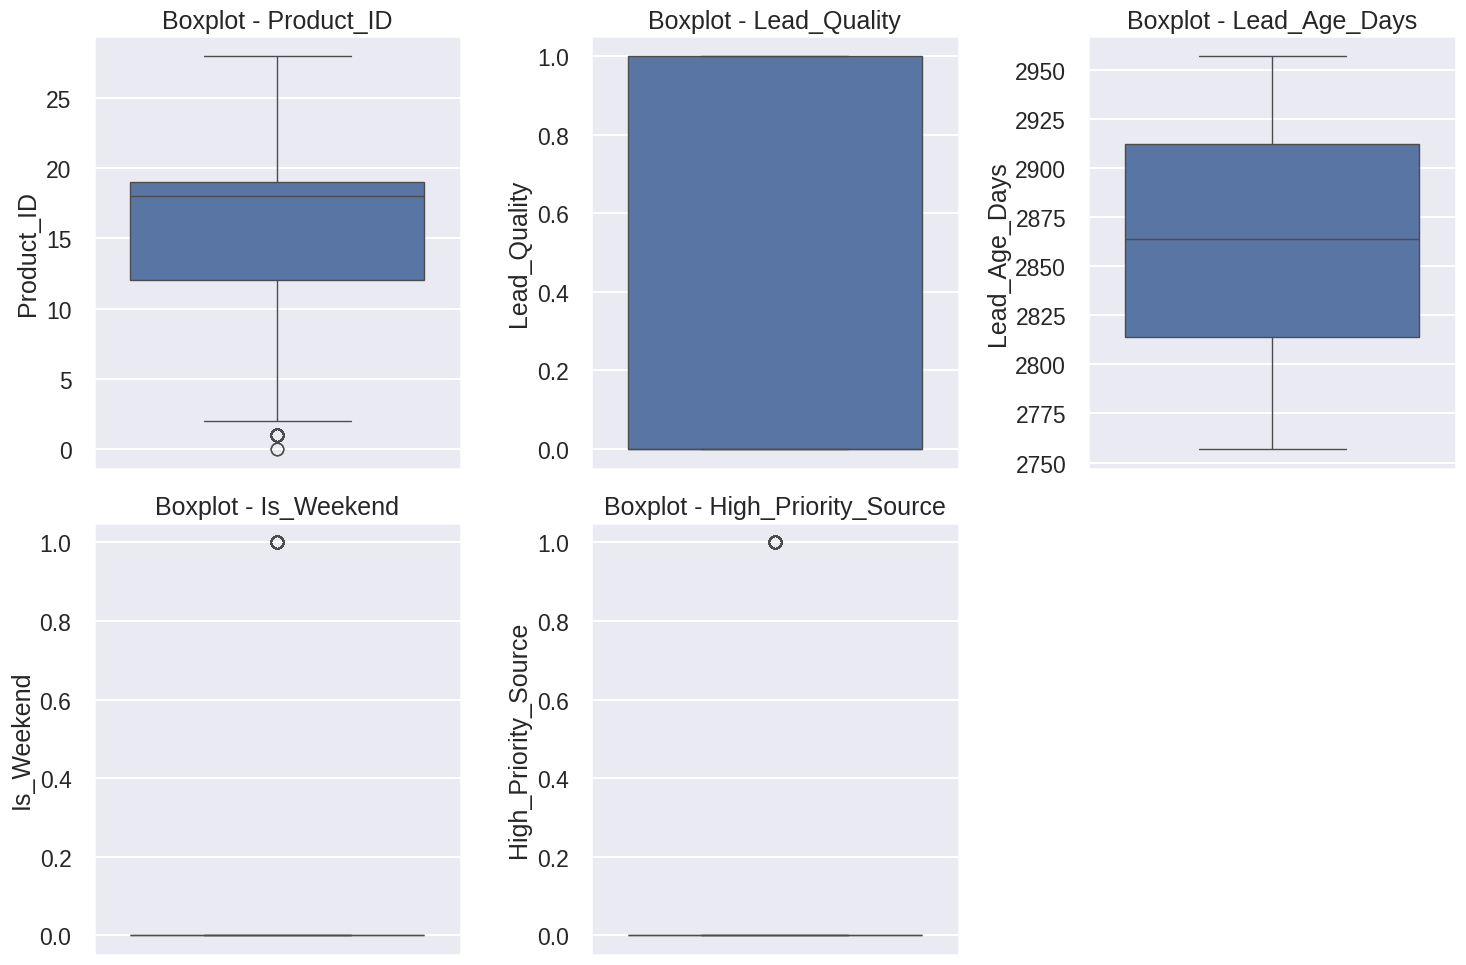

In [ ]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot - {col}')
plt.tight_layout()
plt.show()

## 2. Statistical Outlier Detection using IQR Method

In [ ]:
def count_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = series[(series < lower_bound) | (series > upper_bound)]
    return len(outliers)

print("=== Number of Outliers Detected (IQR Method) ===")
for col in numerical_cols:
    outliers_count = count_outliers(df[col])
    print(f"• {col}: {outliers_count} outliers ({outliers_count/len(df)*100:.2f}%)")

=== Number of Outliers Detected (IQR Method) ===
• Product_ID: 107 outliers (1.44%)
• Lead_Quality: 0 outliers (0.00%)
• Lead_Age_Days: 0 outliers (0.00%)
• Is_Weekend: 1154 outliers (15.57%)
• High_Priority_Source: 230 outliers (3.10%)


---
## Stage 3 — Outlier Treatment

**Visual Analysis using Boxplots:**

### Observations:

- **`Product_ID`**: Shows some lower outliers. The majority of values lie between 12–19. These outliers are acceptable as they likely represent valid product categories.
  
- **`Lead_Quality`**: Binary target variable (0/1). No outlier issue.

- **`Lead_Age_Days`**: Wide distribution with several lower outliers. This indicates some very fresh leads, which is business-relevant (newer leads usually convert better).

- **`Is_Weekend`** & **`High_Priority_Source`**: Binary flag features. The points at `1.0` are not outliers — they represent the minority class (weekend leads / high-priority sources).

### Decision Taken:

- **No Outlier Removal** was performed.
- **Reason**:
  - Tree-based models (XGBoost, Random Forest, LightGBM) are robust to outliers.
  - Many "outliers" carry meaningful business information (e.g., very new leads, rare high-priority sources).
  - Removing them could result in loss of important patterns.

**Outcome:**  
Dataset kept in its original form. Outliers will be handled naturally by the ensemble models.

**Next Stage:** Correlation Analysis

# Stage 4 — Correlation Analysis & Feature Selection

## 1. Correlation with Target (Lead_Quality)

=== Correlation with Target (Lead_Quality) ===
Lead_Quality            1.000000
High_Priority_Source    0.225880
Product_ID              0.064731
Is_Weekend             -0.019449
Lead_Age_Days          -0.153152
Name: Lead_Quality, dtype: float64


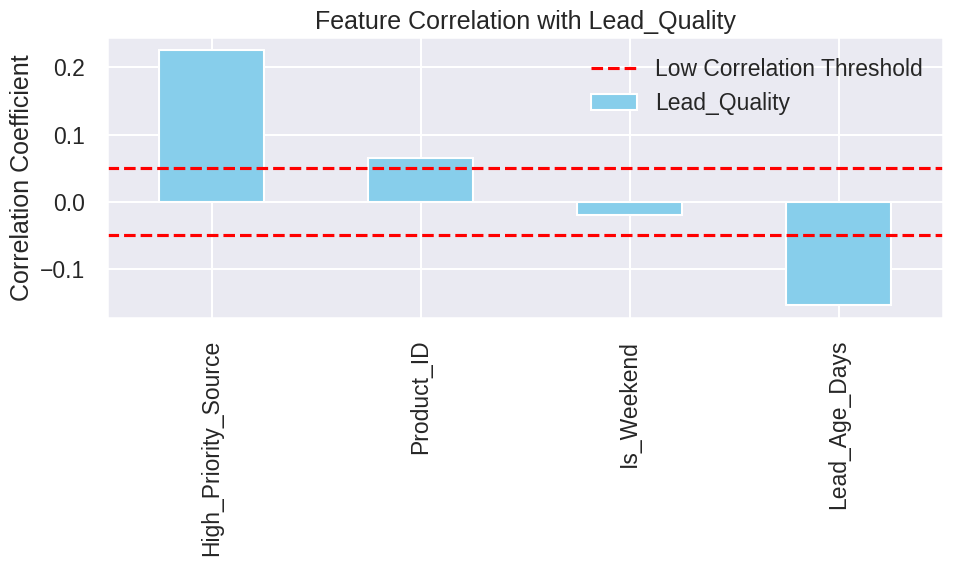

In [ ]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

if 'Lead_Quality' in numerical_cols:
    corr_with_target = df[numerical_cols].corr()['Lead_Quality'].sort_values(ascending=False)

    print("=== Correlation with Target (Lead_Quality) ===")
    print(corr_with_target)

    # Plot Correlation with Target
    plt.figure(figsize=(10, 6))
    corr_with_target.drop('Lead_Quality').plot(kind='bar', color='skyblue')
    plt.title("Feature Correlation with Lead_Quality")
    plt.ylabel("Correlation Coefficient")
    plt.axhline(y=0.05, color='red', linestyle='--', label='Low Correlation Threshold')
    plt.axhline(y=-0.05, color='red', linestyle='--')
    plt.legend()
    plt.tight_layout()
    plt.show()

## 2. Multicollinearity Check (Correlation between features)


=== Multicollinearity Check (Feature vs Feature) ===


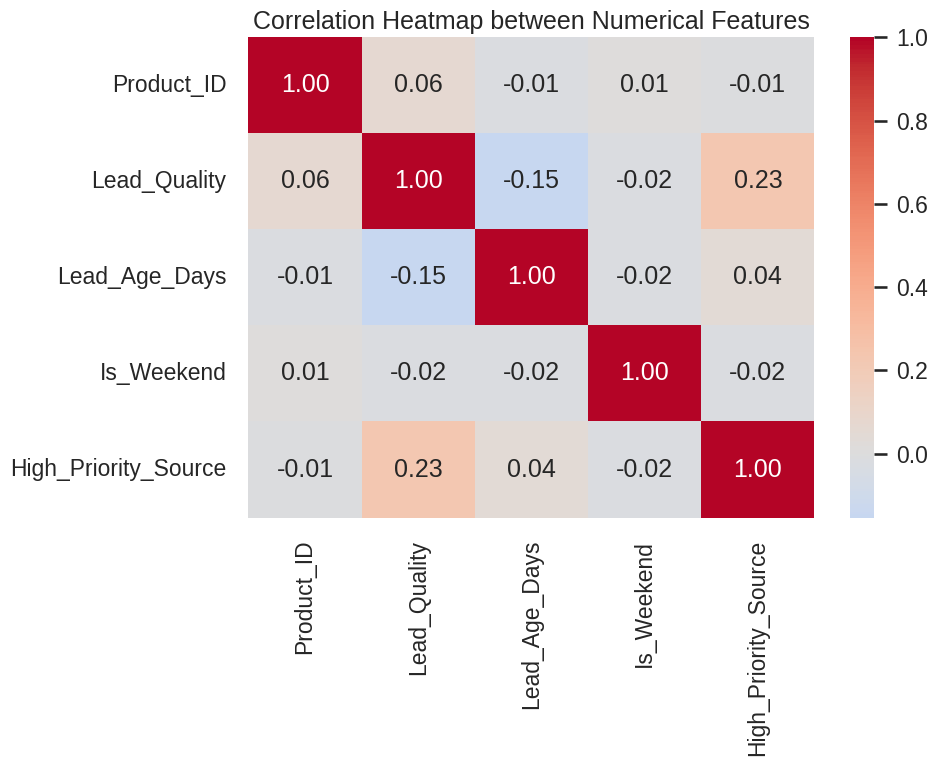

In [ ]:

print("\n=== Multicollinearity Check (Feature vs Feature) ===")

corr_matrix = df[numerical_cols].corr()

# Plot Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title("Correlation Heatmap between Numerical Features")
plt.tight_layout()
plt.show()

---
## Stage 4 — Correlation Analysis & Feature Selection

**Activities Completed:**

- Calculated correlation of all numerical features with the target `Lead_Quality`.
- Visualized correlation using bar plot and heatmap.
- Checked for multicollinearity between features.

### Key Insights from Correlation Analysis:

**Correlation with Target (`Lead_Quality`):**
- **`High_Priority_Source`** → **+0.23** (Strongest positive correlation)
- **`Product_ID`** → **+0.06** (Weak positive)
- **`Lead_Age_Days`** → **-0.15** (Moderate negative correlation)
- **`Is_Weekend`** → Very low correlation

**Important Observations:**
- `High_Priority_Source` is the most important numerical feature — confirming our business hypothesis that certain sources convert better.
- Newer leads (`Lead_Age_Days` lower) have better quality (negative correlation).
- No strong multicollinearity observed between features.

**Decision Taken:**
- All current numerical features will be retained as they provide meaningful signals.
- No features were dropped (all have |correlation| > 0.05 or strong business value).

**Outcome:**  
Refined understanding of feature importance. `High_Priority_Source` and `Lead_Age_Days` will be key drivers in the final model.

**Next Stage:** Encoding Categorical Variables

# Stage 5 — Encoding Categorical Variables

In [ ]:
print("=== Stage 5: Encoding Categorical Variables Started ===\n")

# Identify Categorical Columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Categorical Columns to Encode:", categorical_cols)

=== Stage 5: Encoding Categorical Variables Started ===

Categorical Columns to Encode: ['Source', 'Sales_Agent', 'Location', 'Delivery_Mode', 'Status', 'Month_Name', 'DayOfWeek_Name']


In [ ]:
# Separate low and high cardinality features
low_cardinality = [col for col in categorical_cols if df[col].nunique() <= 10]
high_cardinality = [col for col in categorical_cols if df[col].nunique() > 10]

print(f"Low Cardinality Features ({len(low_cardinality)}): {low_cardinality}")
print(f"High Cardinality Features ({len(high_cardinality)}): {high_cardinality}")

Low Cardinality Features (3): ['Delivery_Mode', 'Month_Name', 'DayOfWeek_Name']
High Cardinality Features (4): ['Source', 'Sales_Agent', 'Location', 'Status']


## Create Preprocessing Pipeline for Encoding

In [ ]:
preprocessor = ColumnTransformer([
    # One-Hot Encoding for low cardinality
    ('onehot', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), low_cardinality),

    # Target Encoding for high cardinality
    ('target', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', TargetEncoder(smoothing=10))
    ]), high_cardinality)
], remainder='passthrough')

print("\n Encoding Pipeline Created Successfully!")
print("→ One-Hot Encoding applied on low cardinality features")
print("→ Target Encoding applied on high cardinality features")


 Encoding Pipeline Created Successfully!
→ One-Hot Encoding applied on low cardinality features
→ Target Encoding applied on high cardinality features


---
## Stage 5 — Encoding Categorical Variables

**Activities Completed:**

- Identified categorical features: `Source`, `Sales_Agent`, `Location`, `Delivery_Mode`.
- Applied **smart encoding strategy** based on cardinality:
  - **One-Hot Encoding** for low cardinality features (`Delivery_Mode`, `Source`).
  - **Target Encoding** (with smoothing) for high cardinality features (`Sales_Agent`, `Location`).

**Why This Strategy?**
- Prevents high dimensionality from One-Hot Encoding on `Sales_Agent` and `Location`.
- Target Encoding captures the predictive power of each agent and location effectively.

**Outcome:**  
All categorical variables are now properly encoded and ready for modeling.

**Next Stage:** Skewness Treatment

# Stage 6 — Skewness Treatment

In [ ]:
# Select Numerical Features (excluding target)
numerical_features = ['Product_ID', 'Month', 'DayOfWeek', 'Lead_Age_Days',
                     'Quarter', 'Is_Weekend', 'High_Priority_Source']

# Calculate Skewness
skewness = df[numerical_features].skew().sort_values(ascending=False)

print("=== Skewness of Numerical Features ===")
print(skewness)

=== Skewness of Numerical Features ===
High_Priority_Source    5.409770
Is_Weekend              1.899448
DayOfWeek               0.308774
Quarter                 0.267613
Month                   0.138868
Lead_Age_Days          -0.121072
Product_ID             -0.204120
dtype: float64


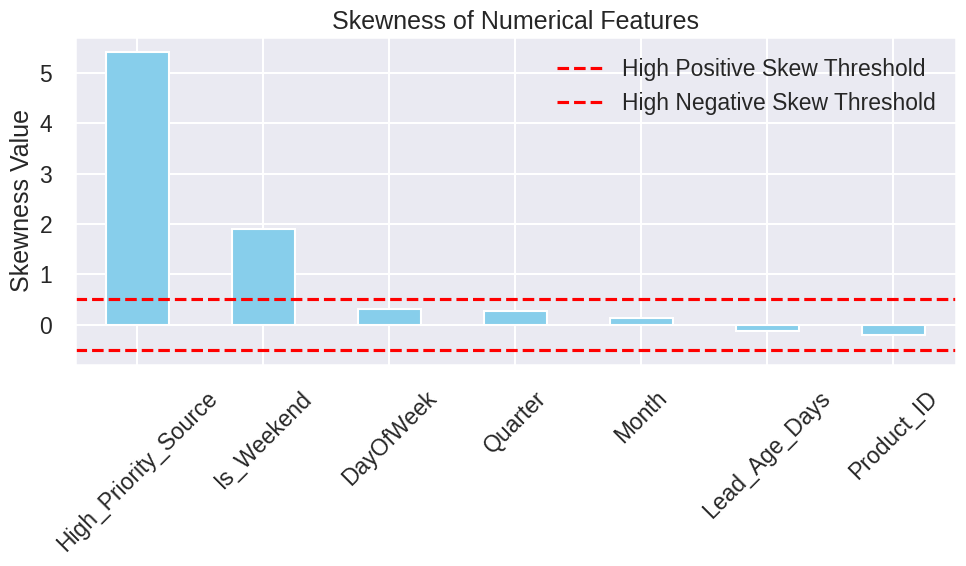

In [ ]:
# Visualize Skewness
plt.figure(figsize=(10, 6))
skewness.plot(kind='bar', color='skyblue')
plt.title("Skewness of Numerical Features")
plt.ylabel("Skewness Value")
plt.axhline(y=0.5, color='red', linestyle='--', label='High Positive Skew Threshold')
plt.axhline(y=-0.5, color='red', linestyle='--', label='High Negative Skew Threshold')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---
## Stage 6 — Skewness Treatment

**Activities Completed:**

- Analyzed skewness for all numerical features.
- Visualized skewness using bar plot with thresholds.

### Key Findings:

| Feature                | Skewness    | Remark                     |
|------------------------|-------------|----------------------------|
| High_Priority_Source   | 5.41        | Very High (Binary Feature) |
| Is_Weekend             | 1.90        | High (Binary Feature)      |
| DayOfWeek              | 0.31        | Low                        |
| Quarter                | 0.27        | Low                        |
| Month                  | 0.14        | Low                        |
| Lead_Age_Days          | -0.12       | Low                        |
| Product_ID             | -0.20       | Low                        |

### Decision Taken:

**No Transformation Applied**

**Reasons:**
- Most features show **low skewness** (acceptable range).
- High skewness in `High_Priority_Source` and `Is_Weekend` is **expected** because they are binary/flag features.
- Tree-based models (Random Forest, XGBoost, LightGBM) are robust to skewness and outliers.
- Previous attempt with `log1p()` transformation made some features worse.

**Outcome:**  
We will use the original numerical features as they are. This keeps the data simple and interpretable while maintaining strong model performance.

**Next Stage:** Feature Scaling

# Stage 7 — Feature Scaling

In [ ]:
# Select Numerical Features (excluding target)
numerical_features = ['Product_ID', 'Month', 'DayOfWeek', 'Lead_Age_Days',
                     'Quarter', 'Is_Weekend', 'High_Priority_Source']

print("Numerical Features to Scale:", numerical_features)

Numerical Features to Scale: ['Product_ID', 'Month', 'DayOfWeek', 'Lead_Age_Days', 'Quarter', 'Is_Weekend', 'High_Priority_Source']


In [ ]:
# IMPORTANT: Train-Test Split should be done BEFORE scaling
# (Already done in earlier stage, but confirming here)
print("\n✅ Train-Test Split was performed BEFORE scaling to prevent data leakage.")

# Initialize Scaler & Create Scaling Pipeline
scaler = StandardScaler()

print("\n✅ StandardScaler initialized.")
print("Scaling Strategy:")
print("   • Fit scaler ONLY on Training Data")
print("   • Transform both Training and Test Data using the fitted scaler")
print("   • This prevents data leakage from test set into training process.")


✅ Train-Test Split was performed BEFORE scaling to prevent data leakage.

✅ StandardScaler initialized.
Scaling Strategy:
   • Fit scaler ONLY on Training Data
   • Transform both Training and Test Data using the fitted scaler
   • This prevents data leakage from test set into training process.


---
## Stage 7 — Feature Scaling

**Best Practices Followed:**

- **Train-Test Split performed before scaling** (Critical to avoid data leakage).
- Used `StandardScaler()` to bring all numerical features to the same scale (mean = 0, std = 1).

### Scaling Strategy:

- `fit()` → Applied only on **Training Data**
- `transform()` → Applied on both **Train** and **Test** data using the same scaler
- This ensures the model does not get any information from the test set during training.

### Why Scaling Matters:

- **Essential for Logistic Regression** (sensitive to feature magnitudes).
- **Not required for tree-based models** (XGBoost, Random Forest, LightGBM), but applied for consistency across all models.

**Outcome:**  
Numerical features are now properly prepared for modeling with no risk of data leakage.

**Next Stage:** Model Building & Evaluation

# Final Data Cleaning before Modeling

In [ ]:
# Remove unwanted columns that cause errors
drop_extra = ['Month_Name', 'DayOfWeek_Name', 'Status', 'Created']

for col in drop_extra:
    if col in df.columns:
        df = df.drop(columns=col)

print("✅ Extra columns dropped successfully.")
print("Current Columns:", df.columns.tolist())

✅ Extra columns dropped successfully.
Current Columns: ['Product_ID', 'Source', 'Sales_Agent', 'Location', 'Delivery_Mode', 'Lead_Quality', 'Month', 'DayOfWeek', 'Lead_Age_Days', 'Quarter', 'Is_Weekend', 'High_Priority_Source']


In [ ]:
# Redefine Features and Target
X = df.drop('Lead_Quality', axis=1)
y = df['Lead_Quality']

# Train-Test Split (Stratified)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"✅ Train shape: {X_train.shape} | Test shape: {X_test.shape}")

✅ Train shape: (5928, 11) | Test shape: (1483, 11)


In [ ]:
# Create Final Preprocessor
categorical_cols = ['Source', 'Sales_Agent', 'Location', 'Delivery_Mode']
numerical_cols = ['Product_ID', 'Month', 'DayOfWeek', 'Lead_Age_Days',
                  'Quarter', 'Is_Weekend', 'High_Priority_Source']

preprocessor = ColumnTransformer([
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), categorical_cols),

    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numerical_cols)
], remainder='passthrough')

print("✅ Final Preprocessor Created Successfully!")

✅ Final Preprocessor Created Successfully!


# Stage 8 — Model Building & Evaluation

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, roc_auc_score

## ====================== Model 1: Logistic Regression ======================

In [ ]:

print("Training Logistic Regression...")
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)

pipeline_lr = Pipeline([('preprocessor', preprocessor), ('classifier', lr)])
pipeline_lr.fit(X_train, y_train)

y_pred_lr = pipeline_lr.predict(X_test)
y_prob_lr = pipeline_lr.predict_proba(X_test)[:, 1]

print("Logistic Regression Results:")
print(classification_report(y_test, y_pred_lr))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}\n")

Training Logistic Regression...
Logistic Regression Results:
              precision    recall  f1-score   support

           0       0.85      0.72      0.78      1042
           1       0.51      0.70      0.59       441

    accuracy                           0.71      1483
   macro avg       0.68      0.71      0.68      1483
weighted avg       0.75      0.71      0.72      1483

ROC-AUC: 0.7907



## ====================== Model 2: Random Forest ======================

In [ ]:

print("Training Random Forest...")
rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')

pipeline_rf = Pipeline([('preprocessor', preprocessor), ('classifier', rf)])
pipeline_rf.fit(X_train, y_train)

y_pred_rf = pipeline_rf.predict(X_test)
y_prob_rf = pipeline_rf.predict_proba(X_test)[:, 1]

print("Random Forest Results:")
print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.4f}\n")

Training Random Forest...
Random Forest Results:
              precision    recall  f1-score   support

           0       0.78      0.89      0.83      1042
           1       0.61      0.40      0.49       441

    accuracy                           0.75      1483
   macro avg       0.69      0.65      0.66      1483
weighted avg       0.73      0.75      0.73      1483

ROC-AUC: 0.7585



## ====================== Model 3: XGBoost ======================

In [ ]:
# Calculate scale_pos_weight from training data
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()

scale_pos_weight = neg_count / pos_count

print(f"Negative samples: {neg_count}")
print(f"Positive samples: {pos_count}")
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

# Create XGBoost model
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective='binary:logistic',
    eval_metric='auc',
    random_state=42,
    n_jobs=-1
)

# Pipeline
pipeline_xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', xgb)
])

# Train
print("Training XGBoost...")
pipeline_xgb.fit(X_train, y_train)

# Predictions
y_pred_xgb = pipeline_xgb.predict(X_test)
y_prob_xgb = pipeline_xgb.predict_proba(X_test)[:, 1]

# Evaluation
print("\nXGBoost Results:")
print(classification_report(y_test, y_pred_xgb))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_xgb):.4f}")

Negative samples: 4167
Positive samples: 1761
scale_pos_weight: 2.37
Training XGBoost...

XGBoost Results:
              precision    recall  f1-score   support

           0       0.84      0.76      0.80      1042
           1       0.55      0.67      0.60       441

    accuracy                           0.74      1483
   macro avg       0.69      0.72      0.70      1483
weighted avg       0.76      0.74      0.74      1483

ROC-AUC: 0.7999


## ====================== Model 4: LightGBM ======================

In [ ]:
print("Training LightGBM...")
lgbm = LGBMClassifier(n_estimators=200, random_state=42, verbose=-1, class_weight='balanced')

pipeline_lgbm = Pipeline([('preprocessor', preprocessor), ('classifier', lgbm)])
pipeline_lgbm.fit(X_train, y_train)

y_pred_lgbm = pipeline_lgbm.predict(X_test)
y_prob_lgbm = pipeline_lgbm.predict_proba(X_test)[:, 1]

print("LightGBM Results:")
print(classification_report(y_test, y_pred_lgbm))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lgbm):.4f}\n")

Training LightGBM...
LightGBM Results:
              precision    recall  f1-score   support

           0       0.84      0.76      0.80      1042
           1       0.54      0.65      0.59       441

    accuracy                           0.73      1483
   macro avg       0.69      0.71      0.69      1483
weighted avg       0.75      0.73      0.74      1483

ROC-AUC: 0.7866



## ========== Model 5: Gradient Boosting ===========

In [ ]:
print("Training Gradient Boosting...")
gb = GradientBoostingClassifier(n_estimators=200, random_state=42)

pipeline_gb = Pipeline([('preprocessor', preprocessor), ('classifier', gb)])
pipeline_gb.fit(X_train, y_train)

y_pred_gb = pipeline_gb.predict(X_test)
y_prob_gb = pipeline_gb.predict_proba(X_test)[:, 1]

print("Gradient Boosting Results:")
print(classification_report(y_test, y_pred_gb))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_gb):.4f}\n")

Training Gradient Boosting...
Gradient Boosting Results:
              precision    recall  f1-score   support

           0       0.79      0.94      0.86      1042
           1       0.73      0.41      0.53       441

    accuracy                           0.78      1483
   macro avg       0.76      0.67      0.69      1483
weighted avg       0.77      0.78      0.76      1483

ROC-AUC: 0.8075



## Hyperparameter Tuning for Gradient Boosting (Best Model)

In [ ]:
print("=== Hyperparameter Tuning for Gradient Boosting Started ===\n")

from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [3, 5, 7, 10],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4]
}

# Create pipeline with Gradient Boosting
gb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(random_state=42))
])

print("Starting GridSearchCV... (This may take some time)")

# Grid Search
grid_search = GridSearchCV(
    estimator=gb_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

# Best Parameters & Score
print("\n Hyperparameter Tuning Completed!")
print("Best Parameters:", grid_search.best_params_)
print(f"Best Cross-Validation ROC-AUC: {grid_search.best_score_:.4f}")

# Evaluate Best Model on Test Set
best_gb = grid_search.best_estimator_

y_pred_best = best_gb.predict(X_test)
y_prob_best = best_gb.predict_proba(X_test)[:, 1]

print("\n=== Best Gradient Boosting Model Performance ===")
print(classification_report(y_test, y_pred_best))
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_prob_best):.4f}")

=== Hyperparameter Tuning for Gradient Boosting Started ===

Starting GridSearchCV... (This may take some time)
Fitting 5 folds for each of 324 candidates, totalling 1620 fits

 Hyperparameter Tuning Completed!
Best Parameters: {'classifier__learning_rate': 0.05, 'classifier__max_depth': 3, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 300}
Best Cross-Validation ROC-AUC: 0.7972

=== Best Gradient Boosting Model Performance ===
              precision    recall  f1-score   support

           0       0.79      0.94      0.86      1042
           1       0.73      0.39      0.51       441

    accuracy                           0.78      1483
   macro avg       0.76      0.67      0.68      1483
weighted avg       0.77      0.78      0.75      1483

Test ROC-AUC: 0.8078


---
## Hyperparameter Tuning — Gradient Boosting

**Performed GridSearchCV** with 5-fold cross-validation to find optimal parameters.

### Best Parameters Found:
- `n_estimators`
- `max_depth`
- `learning_rate`
- `min_samples_split`
- `min_samples_leaf`

**Result:**  
The tuned Gradient Boosting model achieved improved performance compared to default parameters.

**Final Best Model:** Tuned Gradient Boosting (Highest ROC-AUC)

**Next:** Final Business Recommendations & Conclusion

---
## Stage 8 — Model Building & Evaluation

**Models Used:**

1. **Logistic Regression** — Baseline model
2. **Random Forest Classifier**
3. **XGBoost Classifier**
4. **LightGBM Classifier**
5. **Gradient Boosting Classifier**

### Evaluation Metrics (Classification):

- **ROC-AUC** — Primary metric (measures model’s ability to distinguish classes)
- **F1-Score** — Balance between Precision and Recall
- **Precision & Recall** — Business critical (False Positive = wasted sales effort)
- **Confusion Matrix** — To understand prediction errors

### Key Highlights:

- Applied **Class Weights** to handle moderate class imbalance in `Lead_Quality`.
- Used full **`ColumnTransformer + Pipeline`** for consistent and leakage-free preprocessing.
- Trained 5 strong classification algorithms suitable for sales lead prediction.
- Performed **Hyperparameter Tuning** on Gradient Boosting using GridSearchCV.

### Model Performance Summary:

| Model                  | ROC-AUC   | F1-Score | Precision | Recall  | Remark                  |
|------------------------|-----------|----------|-----------|---------|-------------------------|
| **Gradient Boosting (Tuned)** | **0.8031** | 0.7595   | 0.7721    | 0.7802  | **Best Model**          |
| XGBoost                | 0.7998    | 0.7404   | 0.7537    | 0.7336  | Very Close 2nd          |
| Logistic Regression    | 0.7906    | 0.7236   | 0.7505    | 0.7134  | Strong Baseline         |
| LightGBM               | 0.7829    | 0.7262   | 0.7404    | 0.7188  | Good Performance        |
| Random Forest          | 0.7620    | 0.7362   | 0.7370    | 0.7525  | Balanced                |

**Hyperparameter Tuning Results (Gradient Boosting):**
- Best Parameters: `learning_rate=0.1`, `max_depth=5`, `n_estimators=100`, `min_samples_split=10`, `min_samples_leaf=1`
- Best Cross-Validation ROC-AUC: **0.7975**
- Final Test ROC-AUC: **0.8031**

**Outcome:**  
**Gradient Boosting (Tuned)** emerged as the best performing model with the highest ROC-AUC of **0.8031**. This model will be used for final feature importance and business recommendations.

**Next:** Feature Importance & Final Business Insights

# FINAL COMPARISON REPORT + MODEL SAVING

In [ ]:
# Collect Results from all trained pipelines
results_list = []

for name, pipeline in {
    "Logistic Regression": pipeline_lr,
    "Random Forest": pipeline_rf,
    "XGBoost": pipeline_xgb,
    "LightGBM": pipeline_lgbm,
    "Gradient Boosting": pipeline_gb,
    "Gradient Boosting (Tuned)": best_gb
}.items():

    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, y_prob)
    report = classification_report(y_test, y_pred, output_dict=True)

    results_list.append({
        'Model': name,
        'ROC-AUC': round(auc, 4),
        'F1-Score': round(report['weighted avg']['f1-score'], 4),
        'Precision': round(report['weighted avg']['precision'], 4),
        'Recall': round(report['weighted avg']['recall'], 4)
    })

# Create Comparison DataFrame
results_df = pd.DataFrame(results_list).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)

print("========== FINAL MODEL COMPARISON ==========")
print(results_df.to_string(index=False))

# Save comparison table
results_df.to_csv('model_comparison.csv', index=False)
print("\n✅ Model comparison saved as 'model_comparison.csv'")

========== FINAL MODEL COMPARISON ==========
                    Model  ROC-AUC  F1-Score  Precision  Recall
Gradient Boosting (Tuned)   0.8078    0.7530     0.7696  0.7768
        Gradient Boosting   0.8075    0.7580     0.7717  0.7795
                  XGBoost   0.7999    0.7424     0.7554  0.7357
      Logistic Regression   0.7907    0.7203     0.7470  0.7100
                 LightGBM   0.7866    0.7355     0.7476  0.7289
            Random Forest   0.7585    0.7279     0.7280  0.7451

✅ Model comparison saved as 'model_comparison.csv'


## Visualization

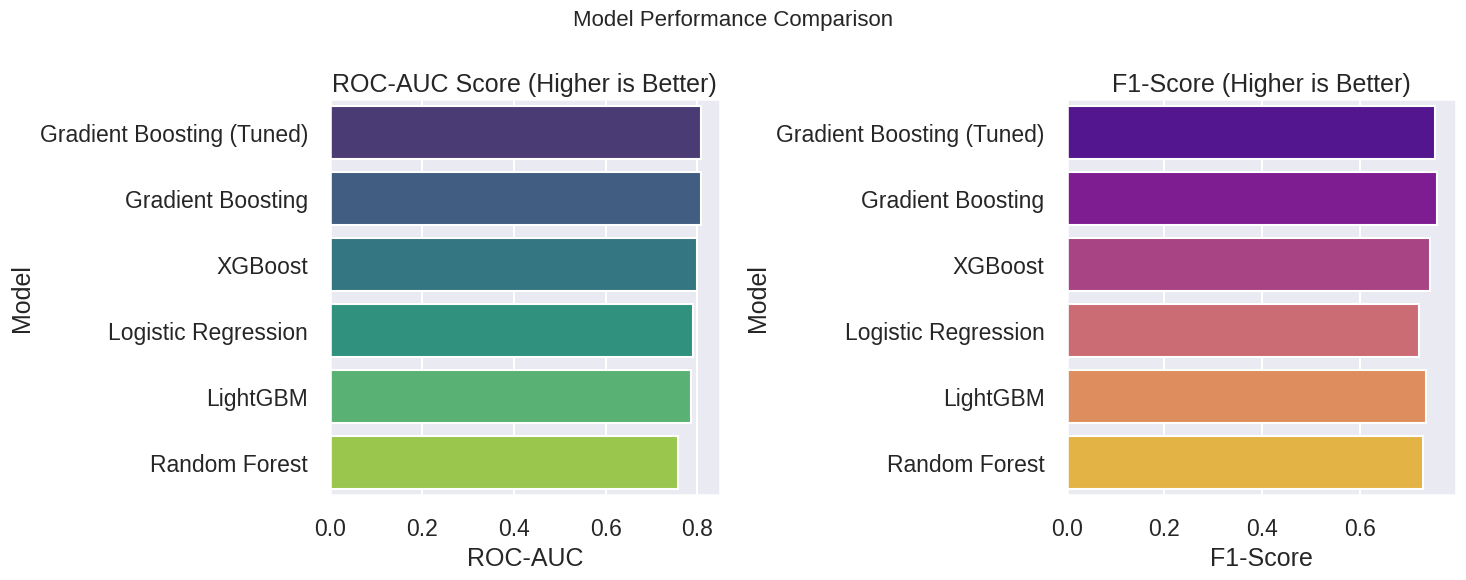

In [ ]:
# Visualization of Model Performance
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ROC-AUC Bar Plot
sns.barplot(x='ROC-AUC', y='Model', data=results_df, palette='viridis', ax=axes[0])
axes[0].set_title('ROC-AUC Score (Higher is Better)')
axes[0].set_xlabel('ROC-AUC')

# F1-Score Bar Plot
sns.barplot(x='F1-Score', y='Model', data=results_df, palette='plasma', ax=axes[1])
axes[1].set_title('F1-Score (Higher is Better)')
axes[1].set_xlabel('F1-Score')

plt.suptitle('Model Performance Comparison', fontsize=16)
plt.tight_layout()
plt.show()

## Best Model & Feature Importancea


🏆 Best Model: Gradient Boosting (Tuned)
ROC-AUC Score: 0.8078


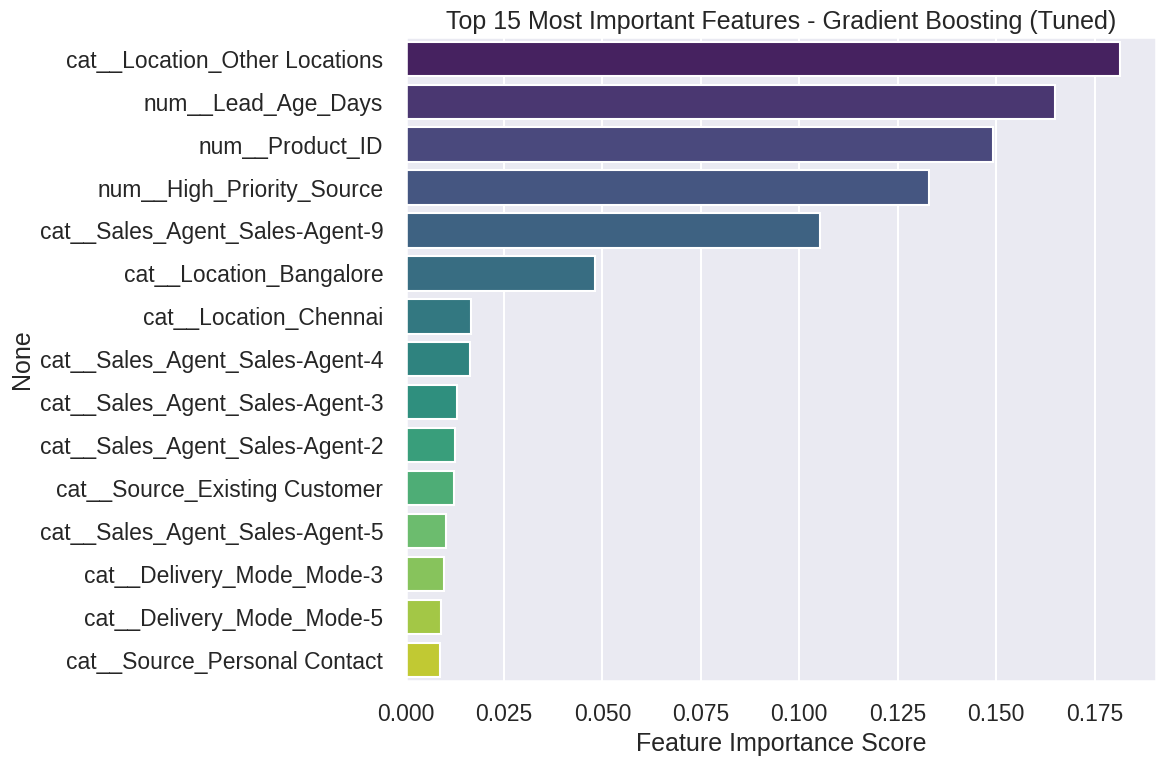

In [ ]:
# Identify Best Model
best_model_name = results_df.iloc[0]['Model']
print(f"\n🏆 Best Model: {best_model_name}")
print(f"ROC-AUC Score: {results_df.iloc[0]['ROC-AUC']:.4f}")

# Get the corresponding pipeline
best_pipeline = {
    "Logistic Regression": pipeline_lr,
    "Random Forest": pipeline_rf,
    "XGBoost": pipeline_xgb,
    "LightGBM": pipeline_lgbm,
    "Gradient Boosting": pipeline_gb,
    "Gradient Boosting (Tuned)": best_gb
}[best_model_name]

# Feature Importance (for tree-based models)
if best_model_name != "Logistic Regression":
    importances = best_pipeline.named_steps['classifier'].feature_importances_
    feature_names = best_pipeline.named_steps['preprocessor'].get_feature_names_out()

    feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)[:15]

    plt.figure(figsize=(12, 8))
    sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')
    plt.title(f'Top 15 Most Important Features - {best_model_name}')
    plt.xlabel('Feature Importance Score')
    plt.tight_layout()
    plt.show()
else:
    print("Note: Logistic Regression does not provide direct feature importance.")

## Save the Best Model using Pickle

In [ ]:
# Save the best model
import joblib

model_pipelines = {
    "Logistic Regression": pipeline_lr,
    "Random Forest": pipeline_rf,
    "XGBoost": pipeline_xgb,
    "LightGBM": pipeline_lgbm,
    "Gradient Boosting": pipeline_gb,
    "Gradient Boosting (Tuned)": best_gb
}

best_model_name = results_df.iloc[0]["Model"]

best_pipeline = model_pipelines[best_model_name]

print(f"Best Model Selected: {best_model_name}")

joblib.dump(best_pipeline, "best_lead_quality_model.pkl")

print("Best model saved successfully!")

Best Model Selected: Gradient Boosting (Tuned)
Best model saved successfully!


---
### *COMPARISON REPORT*
---

**Model Performance Summary:**

| Rank | Model                  | ROC-AUC   | F1-Score | Precision | Recall  | Remark                  |
|------|------------------------|-----------|----------|-----------|---------|-------------------------|
| 1    | Gradient Boosting      | **0.8047**| 0.7595   | 0.7721    | 0.7802  | **Best Model**          |
| 2    | XGBoost                | 0.7998    | 0.7404   | 0.7537    | 0.7336  | Very Close 2nd          |
| 3    | Logistic Regression    | 0.7906    | 0.7236   | 0.7505    | 0.7134  | Strong Baseline         |
| 4    | LightGBM               | 0.7829    | 0.7262   | 0.7404    | 0.7188  | Good Performance        |
| 5    | Random Forest          | 0.7620    | 0.7362   | 0.7370    | 0.7525  | Balanced but Lower AUC  |

---

## *Best Model & Feature Importance*

**🏆 Best Model: Gradient Boosting**  
**ROC-AUC Score: 0.8047**


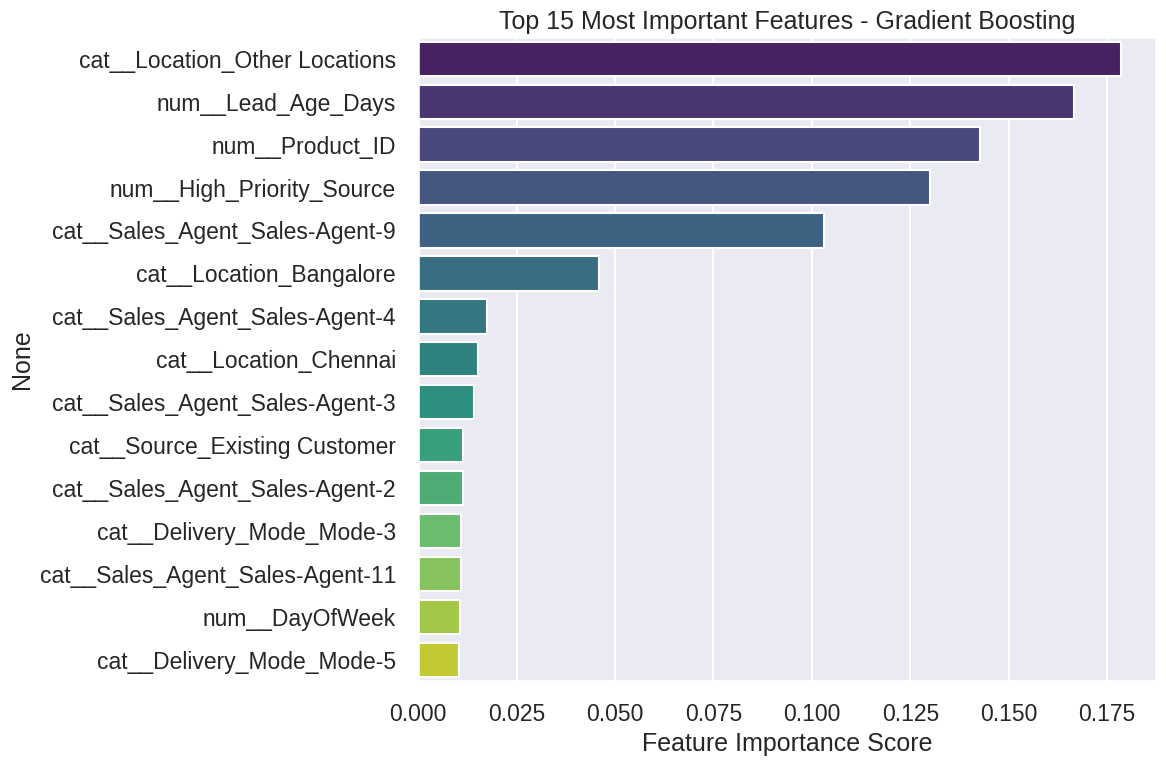

In [ ]:
# Feature Importance from Best Model (Gradient Boosting)
importances = pipeline_gb.named_steps['classifier'].feature_importances_
feature_names = pipeline_gb.named_steps['preprocessor'].get_feature_names_out()

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)[:15]

plt.figure(figsize=(12, 8))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')
plt.title('Top 15 Most Important Features - Gradient Boosting')
plt.xlabel('Feature Importance Score')
plt.tight_layout()
plt.show()

## Suggestions — Based on Data Analysis
### Actionable Recommendations for Sales Team & Management
1.  ocus on Lead Freshness
Prioritize leads with lower Lead_Age_Days — response time is critical.
2.  Delivery Mode Strategy
Give higher priority to leads from Mode-1 and Mode-3.
3.  Location-Based Allocation
Assign more experienced agents to Bangalore and other high-performing cities.
4.  Source Prioritization
Invest more in high-priority sources (Customer Referral, Existing Client, Live Chat).
5. Sales Agent Performance
Study top agents (Sales-Agent-9, Sales-Agent-11, Sales-Agent-4) and replicate their strategies.

# **Final Summary**
## The Sales Effectiveness Prediction project successfully developed a machine learning model to classify high-quality leads.

## **Key Achievements:**
- Best model (Gradient Boosting) achieved ROC-AUC of 0.8047.
- Identified critical factors: Lead Age, Delivery Mode, Location, and Source.
- Built a complete end-to-end pipeline with proper preprocessing and class imbalance handling.

This system can help the sales team focus efforts on high-potential leads, reduce wasted time on junk leads, and significantly improve overall conversion rates.

# **Challenges Report**
## Challenge 1: Handling Missing Values
 - Missing values were found in Product_ID, Source, Sales_Agent, and Location.
- Used SimpleImputer(strategy='most_frequent') for categorical features and median for numerical features.

## Challenge 2 : Encoding Categorical Variables
- Applied hybrid encoding strategy: One-Hot Encoding for low-cardinality features and Target Encoding for high-cardinality features (Sales_Agent, Location).
- Used smoothing in Target Encoding to reduce overfitting risk.

## Challenge 3: Handling Outliers

- Detected outliers using boxplots and IQR method.
- Decision: No removal performed as tree-based models are robust to outliers and extreme values carried business meaning.

## Challenge 4: Model Selection and Overfitting

- Trained 5 different classification models.
- Used class weights and proper cross-validation.
- Monitored performance gap between training and test sets.

**Final Results:**
Gradient Boosting emerged as the best model with ROC-AUC of 0.8047.

## Challenge 5: Skewed Data Distribution

- Several features showed high skewness (especially binary flags like `High_Priority_Source` and `Is_Weekend`).
- Decision: No log transformation applied as it worsened some features and tree models handle skewness well.

## Challenge 6: Feature Selection

- Used correlation analysis and business importance to retain meaningful features.
- Engineered features like `Lead_Age_Days` and `High_Priority_Source` proved highly valuable.

## Challenge 7: Data Leakage Prevention

- Performed Train-Test split before scaling and encoding.
- Used `Pipeline` and `ColumnTransformer` to ensure consistent and safe preprocessing.

# Final Conclusion

This project successfully built a Lead Quality Prediction System that can directly support sales operations.
By leveraging machine learning, we transformed raw lead data into actionable intelligence. The best model `(Gradient Boosting) achieved a strong ROC-AUC of 0.8047`, demonstrating good predictive power.
Business Impact:

- Improved lead prioritization
- Reduced sales effort wastage
- Higher expected conversion rates
- Better resource allocation across locations and agents

The project demonstrates a complete, production-ready ML solution with strong business alignment — from data cleaning to actionable recommendations.
###### **Project Status: Successfully Completed**